In [175]:
import pandas as pd
import matplotlib as plt 



In [91]:
# Using 'r' before the string creates a raw string to avoid Windows path errors
file_path = r"C:\Users\Raghav\OneDrive\Desktop\Projects\HI-Small_Trans.csv"

# Read the CSV file
df = pd.read_csv(file_path)

# Preview the first 5 rows
print(df.head())

          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97          US Dollar     36682.97        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1         Cheque              0  
2   Reinvestment              0  
3   Reinvestment              0  
4   Reinvest

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [93]:
df.isnull().sum()

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [94]:
# Check the laundering distribution

print(df["Is Laundering"].value_counts())

print("\nPercentage:")
print(df["Is Laundering"].value_counts(normalize=True).mul(100).round(4))

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

Percentage:
Is Laundering
0    99.8981
1     0.1019
Name: proportion, dtype: float64


In [95]:
missing = pd.DataFrame(
    {"Missing": df.isnull().sum(), "Percentage": (df.isnull().mean() * 100).round(2)}
)

missing

,Missing,Percentage
Timestamp,0,0.0
From Bank,0,0.0
Account,0,0.0
To Bank,0,0.0
Account.1,0,0.0
Amount Received,0,0.0
Receiving Currency,0,0.0
Amount Paid,0,0.0
Payment Currency,0,0.0
Payment Format,0,0.0


In [96]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 9


In [97]:
laundering = df[df["Is Laundering"] == 1]

print("Laundering transactions:", len(laundering))

display(laundering)

Laundering transactions: 5177


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
4742,2022/09/01 00:21,70,100428660,1124,800825340,389769.39,US Dollar,389769.39,US Dollar,Cheque,1
40621,2022/09/01 00:03,70,100428660,11474,805B716C0,29024.33,US Dollar,29024.33,US Dollar,Credit Card,1
69152,2022/09/01 00:01,70,100428660,15980,80B39E7B0,792.92,US Dollar,792.92,US Dollar,Credit Card,1
85763,2022/09/01 00:03,70,100428660,113798,80DC756E0,13171425.53,US Dollar,13171425.53,US Dollar,Cheque,1
90684,2022/09/01 00:23,70,100428660,32375,80E480620,14288.83,US Dollar,14288.83,US Dollar,Cash,1
...,...,...,...,...,...,...,...,...,...,...,...
5071168,2022/09/10 23:29,111433,8065C2380,21550,8065C69E0,7773.42,US Dollar,7773.42,US Dollar,ACH,1
5073375,2022/09/10 23:07,9,80727F930,219557,8072A28C0,448920.65,Ruble,448920.65,Ruble,Cheque,1
5074248,2022/09/12 03:34,222,812D127D0,50202,812D129C0,20085.71,Saudi Riyal,20085.71,Saudi Riyal,ACH,1
5075056,2022/09/10 23:43,17327,8095F6C20,15695,8095F6C70,3314.36,US Dollar,3314.36,US Dollar,ACH,1


In [98]:
laundering.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,5177,4442,2022/09/05 11:45,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
From Bank,5177.0,NaN,NaN,NaN,45140.643809,73273.351129,1.0,119.0,11974.0,29788.0,254958.0
Account,5177,3376,100428660,243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
To Bank,5177.0,NaN,NaN,NaN,50677.895306,73979.4736,1.0,1502.0,16649.0,48309.0,256229.0
Account.1,5177,3984,811C599A0,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount Received,5177.0,NaN,NaN,NaN,36135310.412813,1527918669.798135,0.003227,2634.97,8667.21,18832.27,84853144179.580002
Receiving Currency,5177,15,US Dollar,1912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount Paid,5177.0,NaN,NaN,NaN,36135310.412813,1527918669.798135,0.003227,2634.97,8667.21,18832.27,84853144179.580002
Payment Currency,5177,15,US Dollar,1912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment Format,5177,5,ACH,4483,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\Raghav\OneDrive\Desktop\Projects\HI-Small_Trans.csv"

# Define optimized data types
dtype = {
    "From Bank": "int32",
    "To Bank": "int32",
    "Amount Received": "float32",
    "Amount Paid": "float32",
    "Is Laundering": "int8",
}

# Load full dataset
df = pd.read_csv(file_path, dtype=dtype)

print("Shape:", df.shape)
print("\nMemory usage:")
print(f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (5078345, 11)

Memory usage:
1779.57 MB


In [100]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename account.1
df = df.rename(columns={"account": "sender_account", "account.1": "receiver_account"})

print(df.columns.tolist())

['timestamp', 'from_bank', 'sender_account', 'to_bank', 'receiver_account', 'amount_received', 'receiving_currency', 'amount_paid', 'payment_currency', 'payment_format', 'is_laundering']


In [101]:
target_counts = df["is_laundering"].value_counts()

normal = target_counts.get(0, 0)
laundering = target_counts.get(1, 0)

print("Normal transactions:", normal)
print("Laundering transactions:", laundering)

print("\nPercentages:")
print(df["is_laundering"].value_counts(normalize=True).mul(100).round(6))

print("\nImbalance ratio:")
print(f"1 : {normal / laundering:.0f}")

Normal transactions: 5073168
Laundering transactions: 5177

Percentages:
is_laundering
0    99.898057
1     0.101943
Name: proportion, dtype: float64

Imbalance ratio:
1 : 980


In [102]:
payment_analysis = (
    df.groupby("payment_format", observed=True)
    .agg(
        transactions=("is_laundering", "size"),
        laundering=("is_laundering", "sum"),
        laundering_rate=("is_laundering", "mean"),
    )
    .sort_values("laundering_rate", ascending=False)
)

payment_analysis

,transactions,laundering,laundering_rate
payment_format,,,
ACH,600797,4483,0.007462
Bitcoin,146091,56,0.000383
Cash,490891,108,0.000220
Cheque,1864331,324,0.000174
Credit Card,1323324,206,0.000156
Reinvestment,481056,0,0.000000
Wire,171855,0,0.000000


In [103]:
amount_analysis = df.groupby("is_laundering")[["amount_received", "amount_paid"]].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

amount_analysis

amount_received                                         \
                        count        mean       median           std   
is_laundering                                                          
0                     5073168   5957962.5  1407.510010  1.036563e+09   
1                        5177  36135312.0  8667.209961  1.527919e+09   

                                      amount_paid                           \
                    min           max       count        mean       median   
is_laundering                                                                
0              0.000001  1.046302e+12     5073168   4477000.0  1410.989990   
1              0.003227  8.485315e+10        5177  36135312.0  8667.209961   

                                                     
                        std       min           max  
is_laundering                                        
0              8.688463e+08  0.000001  1.046302e+12  
1              1.527919e+09  0.003227  8.485315e+10

In [104]:
df.groupby("is_laundering")[["amount_received", "amount_paid"]].median()

,amount_received,amount_paid
is_laundering,,
0,1407.510010,1410.989990
1,8667.209961,8667.209961


In [105]:
currency_analysis = (
    df.groupby("receiving_currency", observed=True)
    .agg(
        transactions=("is_laundering", "size"),
        laundering=("is_laundering", "sum"),
        laundering_rate=("is_laundering", "mean"),
    )
    .sort_values("laundering_rate", ascending=False)
)

currency_analysis

,transactions,laundering,laundering_rate
receiving_currency,,,
Saudi Riyal,89971,374,0.004157
Euro,1172017,1372,0.001171
US Dollar,1879341,1912,0.001017
Yen,156319,155,0.000992
Australian Dollar,138511,127,0.000917
Canadian Dollar,141357,128,0.000906
Yuan,206551,184,0.000891
Rupee,192065,167,0.000869
Ruble,157361,133,0.000845


In [106]:
currency_paid_analysis = (
    df.groupby("payment_currency", observed=True)
    .agg(
        transactions=("is_laundering", "size"),
        laundering=("is_laundering", "sum"),
        laundering_rate=("is_laundering", "mean"),
    )
    .sort_values("laundering_rate", ascending=False)
)

currency_paid_analysis

,transactions,laundering,laundering_rate
payment_currency,,,
Saudi Riyal,89014,374,0.004202
Euro,1168297,1372,0.001174
US Dollar,1895172,1912,0.001009
Yen,155209,155,0.000999
Australian Dollar,136769,127,0.000929
Canadian Dollar,140042,128,0.000914
Rupee,190202,167,0.000878
Yuan,213752,184,0.000861
Ruble,155178,133,0.000857


In [107]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2022-09-01 00:00:00
End: 2022-09-18 16:18:00


In [108]:
# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Create time features
df["hour"] = df["timestamp"].dt.hour.astype("int8")
df["day_of_week"] = df["timestamp"].dt.dayofweek.astype("int8")

print(df[["timestamp", "hour", "day_of_week"]].head())

            timestamp  hour  day_of_week
0 2022-09-01 00:20:00     0            3
1 2022-09-01 00:20:00     0            3
2 2022-09-01 00:00:00     0            3
3 2022-09-01 00:02:00     0            3
4 2022-09-01 00:06:00     0            3


In [109]:
# ============================================
# MULEGUARD — STEP 1
# Basic Transaction Features
# ============================================

import pandas as pd
import numpy as np

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Time features
df["hour"] = df["timestamp"].dt.hour.astype("int8")
df["day_of_week"] = df["timestamp"].dt.dayofweek.astype("int8")

# Amount features
df["amount_diff"] = df["amount_received"] - df["amount_paid"]

df["amount_ratio"] = df["amount_received"] / (df["amount_paid"] + 1e-6)

# Currency relationship
df["currency_match"] = (df["receiving_currency"] == df["payment_currency"]).astype(
    "int8"
)

# Bank relationship
df["same_bank"] = (df["from_bank"] == df["to_bank"]).astype("int8")

print("Feature engineering completed.")
print("Shape:", df.shape)

print("\nNew columns:")
print(
    [
        "hour",
        "day_of_week",
        "amount_diff",
        "amount_ratio",
        "currency_match",
        "same_bank",
    ]
)

Feature engineering completed.
Shape: (5078345, 17)

New columns:
['hour', 'day_of_week', 'amount_diff', 'amount_ratio', 'currency_match', 'same_bank']


In [110]:
print(df.columns.tolist())

['timestamp', 'from_bank', 'sender_account', 'to_bank', 'receiver_account', 'amount_received', 'receiving_currency', 'amount_paid', 'payment_currency', 'payment_format', 'is_laundering', 'hour', 'day_of_week', 'amount_diff', 'amount_ratio', 'currency_match', 'same_bank']


In [111]:
# ============================================
# MULEGUARD — STEP 2A
# Sender Account Behavioral Features
# ============================================

sender_features = (
    df.groupby("sender_account")
    .agg(
        sender_transaction_count=("sender_account", "size"),
        sender_total_amount=("amount_paid", "sum"),
        sender_avg_amount=("amount_paid", "mean"),
        sender_max_amount=("amount_paid", "max"),
        sender_unique_receivers=("receiver_account", "nunique"),
        sender_unique_banks=("to_bank", "nunique"),
    )
    .reset_index()
)

print("Sender features created.")
print("Shape:", sender_features.shape)

sender_features.head()

Sender features created.
Shape: (496995, 7)


,sender_account,sender_transaction_count,sender_total_amount,sender_avg_amount,sender_max_amount,sender_unique_receivers,sender_unique_banks
0,100428660,168672,5.276229e+10,3.128100e+05,1.615849e+09,14230,618
1,1004286A8,103018,2.606937e+10,2.530565e+05,8.258079e+08,8846,393
2,1004286F0,18663,2.465736e+10,1.321189e+06,1.140426e+09,1575,87
3,100428738,13756,2.592168e+11,1.884391e+07,2.984402e+10,1136,42
4,100428780,17264,3.739337e+11,2.165974e+07,2.716420e+10,1421,59


In [112]:
# ============================================
# MULEGUARD — STEP 2B
# Receiver Account Behavioral Features
# ============================================

receiver_features = (
    df.groupby("receiver_account")
    .agg(
        receiver_transaction_count=("receiver_account", "size"),
        receiver_total_amount=("amount_received", "sum"),
        receiver_avg_amount=("amount_received", "mean"),
        receiver_max_amount=("amount_received", "max"),
        receiver_unique_senders=("sender_account", "nunique"),
        receiver_unique_banks=("from_bank", "nunique"),
    )
    .reset_index()
)

print("Receiver features created.")
print("Shape:", receiver_features.shape)

receiver_features.head()

Receiver features created.
Shape: (420636, 7)


,receiver_account,receiver_transaction_count,receiver_total_amount,receiver_avg_amount,receiver_max_amount,receiver_unique_senders,receiver_unique_banks
0,100428660,1084,4.795948e+05,442.430603,5.551910e+03,545,494
1,1004286A8,653,2.510013e+05,384.381714,4.299750e+03,328,301
2,1004286F0,108,2.539339e+05,2351.239502,1.461206e+04,55,51
3,100428738,98,6.304388e+06,64330.496094,3.841394e+05,51,47
4,100428780,117,1.057089e+07,90349.484375,3.188130e+06,61,56


In [113]:
# ============================================
# MULEGUARD — STEP 2C
# Merge Account Behavioral Features
# ============================================

# Merge sender features
df = df.merge(sender_features, on="sender_account", how="left")

# Merge receiver features
df = df.merge(receiver_features, on="receiver_account", how="left")

print("Account features merged.")
print("New shape:", df.shape)

Account features merged.
New shape: (5078345, 29)


In [114]:
# ============================================
# MULEGUARD — STEP 3A
# Transaction Velocity
# ============================================

# Sort transactions chronologically for each sender
df = df.sort_values(["sender_account", "timestamp"]).reset_index(drop=True)

# Time since previous transaction by sender
df["seconds_since_previous"] = (
    df.groupby("sender_account")["timestamp"].diff().dt.total_seconds()
)

# First transaction for an account has no previous transaction
df["seconds_since_previous"] = df["seconds_since_previous"].fillna(999999)

print("Transaction velocity feature created.")

print(df["seconds_since_previous"].describe())

Transaction velocity feature created.
count    5.078345e+06
mean     1.319948e+05
std      3.021398e+05
min      0.000000e+00
25%      3.000000e+02
50%      1.380000e+03
75%      5.850000e+04
max      1.194480e+06
Name: seconds_since_previous, dtype: float64


In [115]:
print(df.shape)
print(df.columns.tolist())

(5078345, 30)
['timestamp', 'from_bank', 'sender_account', 'to_bank', 'receiver_account', 'amount_received', 'receiving_currency', 'amount_paid', 'payment_currency', 'payment_format', 'is_laundering', 'hour', 'day_of_week', 'amount_diff', 'amount_ratio', 'currency_match', 'same_bank', 'sender_transaction_count', 'sender_total_amount', 'sender_avg_amount', 'sender_max_amount', 'sender_unique_receivers', 'sender_unique_banks', 'receiver_transaction_count', 'receiver_total_amount', 'receiver_avg_amount', 'receiver_max_amount', 'receiver_unique_senders', 'receiver_unique_banks', 'seconds_since_previous']


In [116]:
# ============================================
# MULEGUARD — STEP 4A
# Restore chronological order
# ============================================

df = df.sort_values("timestamp").reset_index(drop=True)

print("Data sorted chronologically.")
print(df[["timestamp", "sender_account", "receiver_account"]].head())
print(df[["timestamp", "sender_account", "receiver_account"]].tail())

Data sorted chronologically.
   timestamp sender_account receiver_account
0 2022-09-01      100428660        8006493B0
1 2022-09-01      80631DC50        806350010
2 2022-09-01      80476C1E0        80476C1E0
3 2022-09-01      801B64CE0        801B64CE0
4 2022-09-01      811D95890        8127C5770
                  timestamp sender_account receiver_account
5078340 2022-09-18 10:02:00      8043A0FB0        802F78670
5078341 2022-09-18 11:18:00      8043A0FB0        8095526B0
5078342 2022-09-18 11:18:00      8043A0FB0        8043A0FB0
5078343 2022-09-18 12:58:00      8043A0FB0        8026687E0
5078344 2022-09-18 16:18:00      8043A0FB0        809320130


In [117]:
# ============================================
# MULEGUARD — STEP 4
# Time-Based Train / Validation / Test Split
# ============================================

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Calculate split points
start_time = df["timestamp"].min()
end_time = df["timestamp"].max()

total_duration = end_time - start_time

train_end = start_time + (total_duration * 0.70)
val_end = start_time + (total_duration * 0.85)

print("Start :", start_time)
print("Train :", train_end)
print("Val   :", val_end)
print("End   :", end_time)

# Split
train_df = df[df["timestamp"] <= train_end].copy()

val_df = df[(df["timestamp"] > train_end) & (df["timestamp"] <= val_end)].copy()

test_df = df[df["timestamp"] > val_end].copy()

print("\nShapes:")
print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

Start : 2022-09-01 00:00:00
Train : 2022-09-13 09:00:35.999999999
Val   : 2022-09-16 00:39:18
End   : 2022-09-18 16:18:00

Shapes:
Train      : (5077971, 30)
Validation : (300, 30)
Test       : (74, 30)


In [118]:
# ============================================
# MULEGUARD — STEP 4B
# Transaction Distribution by Date
# ============================================

daily_counts = (
    df.groupby(df["timestamp"].dt.date)
    .agg(transactions=("is_laundering", "size"), laundering=("is_laundering", "sum"))
    .reset_index()
)

daily_counts["laundering_pct"] = (
    daily_counts["laundering"] / daily_counts["transactions"] * 100
)

print(daily_counts.to_string(index=False))

 timestamp  transactions  laundering  laundering_pct
2022-09-01       1114921         322        0.028881
2022-09-02        754449         408        0.054079
2022-09-03        207382         391        0.188541
2022-09-04        207430         407        0.196211
2022-09-05        482650         471        0.097586
2022-09-06        482089         531        0.110146
2022-09-07        482751         497        0.102952
2022-09-08        482773         539        0.111647
2022-09-09        654467         514        0.078537
2022-09-10        208325         442        0.212168
2022-09-11           396         232       58.585859
2022-09-12           281         170       60.498221
2022-09-13           184         106       57.608696
2022-09-14           121          70       57.851240
2022-09-15            46          28       60.869565
2022-09-16            46          26       56.521739
2022-09-17            23          15       65.217391
2022-09-18            11           8       72.

In [119]:
# ============================================
# MULEGUARD — STEP 4C
# High-volume period distribution
# ============================================

model_df = df[df["timestamp"].dt.date <= pd.to_datetime("2022-09-10").date()].copy()

print("Modeling dataset shape:", model_df.shape)

print("\nClass distribution:")
print(model_df["is_laundering"].value_counts())

print("\nClass percentages:")
print(model_df["is_laundering"].value_counts(normalize=True) * 100)

print("\nDate range:")
print(model_df["timestamp"].min())
print(model_df["timestamp"].max())

Modeling dataset shape: (5077237, 30)

Class distribution:
is_laundering
0    5072715
1       4522
Name: count, dtype: int64

Class percentages:
is_laundering
0    99.910936
1     0.089064
Name: proportion, dtype: float64

Date range:
2022-09-01 00:00:00
2022-09-10 23:59:00


In [120]:
# ============================================
# MULEGUARD — STEP 5
# Chronological Model Split
# ============================================

train_df = model_df[model_df["timestamp"] < "2022-09-08"].copy()

val_df = model_df[
    (model_df["timestamp"] >= "2022-09-08") & (model_df["timestamp"] < "2022-09-10")
].copy()

test_df = model_df[model_df["timestamp"] >= "2022-09-10"].copy()

print("TRAIN")
print(train_df.shape)

print("\nVALIDATION")
print(val_df.shape)

print("\nTEST")
print(test_df.shape)

TRAIN
(3731672, 30)

VALIDATION
(1137240, 30)

TEST
(208325, 30)


In [121]:
# ============================================
# CREATE DATA SPLITS + LIGHTGBM DATA
# RUN THIS WHOLE CELL
# ============================================

import numpy as np
import pandas as pd

# --------------------------------------------
# 1. Sort chronologically
# --------------------------------------------

df = df.sort_values("timestamp").reset_index(drop=True)

print("Full dataset:", df.shape)


# --------------------------------------------
# 2. Create train / validation / test
# --------------------------------------------

train_size = 3_731_672
val_size = 1_137_240
test_size = 208_325

train = df.iloc[:train_size].copy()

validation = df.iloc[train_size : train_size + val_size].copy()

test = df.iloc[train_size + val_size : train_size + val_size + test_size].copy()


# --------------------------------------------
# 3. Verify splits
# --------------------------------------------

print("\nTRAIN:", train.shape)
print("VALIDATION:", validation.shape)
print("TEST:", test.shape)


# --------------------------------------------
# 4. Prepare LightGBM features
# --------------------------------------------

target = "is_laundering"

drop_columns = ["is_laundering", "timestamp", "sender_account", "receiver_account"]

X_train = train.drop(columns=drop_columns)
y_train = train[target]

X_val = validation.drop(columns=drop_columns)
y_val = validation[target]

X_test = test.drop(columns=drop_columns)
y_test = test[target]


# --------------------------------------------
# 5. Check final shapes
# --------------------------------------------

print("\n==============================")
print("LIGHTGBM DATA")
print("==============================")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# --------------------------------------------
# 6. Feature list
# --------------------------------------------

print("\nMODEL FEATURES:")
for i, col in enumerate(X_train.columns, 1):
    print(f"{i:2}. {col}")


# --------------------------------------------
# 7. Target distribution
# --------------------------------------------

print("\nTRAIN TARGET DISTRIBUTION:")
print(y_train.value_counts())

print("\nVALIDATION TARGET DISTRIBUTION:")
print(y_val.value_counts())

print("\nTEST TARGET DISTRIBUTION:")
print(y_test.value_counts())

Full dataset: (5078345, 30)

TRAIN: (3731672, 30)
VALIDATION: (1137240, 30)
TEST: (208325, 30)

LIGHTGBM DATA
X_train: (3731672, 26)
y_train: (3731672,)
X_val: (1137240, 26)
y_val: (1137240,)
X_test: (208325, 26)
y_test: (208325,)

MODEL FEATURES:
 1. from_bank
 2. to_bank
 3. amount_received
 4. receiving_currency
 5. amount_paid
 6. payment_currency
 7. payment_format
 8. hour
 9. day_of_week
10. amount_diff
11. amount_ratio
12. currency_match
13. same_bank
14. sender_transaction_count
15. sender_total_amount
16. sender_avg_amount
17. sender_max_amount
18. sender_unique_receivers
19. sender_unique_banks
20. receiver_transaction_count
21. receiver_total_amount
22. receiver_avg_amount
23. receiver_max_amount
24. receiver_unique_senders
25. receiver_unique_banks
26. seconds_since_previous

TRAIN TARGET DISTRIBUTION:
is_laundering
0    3728645
1       3027
Name: count, dtype: int64

VALIDATION TARGET DISTRIBUTION:
is_laundering
0    1136187
1       1053
Name: count, dtype: int64

TEST TA

In [122]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.5.0


In [123]:
# ============================================
# CLASS IMBALANCE WEIGHT
# ============================================

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples :", negative)
print("Positive samples :", positive)
print("Scale Pos Weight :", scale_pos_weight)

Negative samples : 3728645
Positive samples : 3027
Scale Pos Weight : 1231.795507102742


In [124]:
# ============================================
# MULEGUARD - LIGHTGBM TRAINING
# ============================================

import lightgbm as lgb
import joblib
import os
import time

# --------------------------------------------
# 1. Identify categorical features
# --------------------------------------------

categorical_features = ["receiving_currency", "payment_currency", "payment_format"]

# Convert categorical columns to category dtype
for col in categorical_features:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")


# --------------------------------------------
# 2. LightGBM parameters
# --------------------------------------------

params = {
    "objective": "binary",
    # Evaluation
    "metric": "average_precision",
    # Model capacity
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    # Minimum data per leaf
    "min_child_samples": 100,
    # Feature / row sampling
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    # Regularization
    "lambda_l1": 0.1,
    "lambda_l2": 1.0,
    # Extreme class imbalance
    "scale_pos_weight": scale_pos_weight,
    # Performance
    "verbosity": -1,
    "n_jobs": -1,
    # Reproducibility
    "seed": 42,
    "feature_fraction_seed": 42,
    "bagging_seed": 42,
    "data_random_seed": 42,
}


# --------------------------------------------
# 3. Create LightGBM datasets
# --------------------------------------------

train_data = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=categorical_features,
    free_raw_data=False,
)

val_data = lgb.Dataset(
    X_val,
    label=y_val,
    categorical_feature=categorical_features,
    reference=train_data,
    free_raw_data=False,
)


# --------------------------------------------
# 4. Train
# --------------------------------------------

print("Starting LightGBM training...")
print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Features:", X_train.shape[1])
print("Scale pos weight:", scale_pos_weight)

start_time = time.time()

model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, val_data],
    valid_names=["train", "validation"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

training_time = time.time() - start_time

print("\n================================")
print("TRAINING COMPLETE")
print("================================")

print(f"Training time: {training_time / 60:.2f} minutes")
print("Best iteration:", model.best_iteration)
print("Best score:", model.best_score)

Starting LightGBM training...
Training rows: 3731672
Validation rows: 1137240
Features: 26
Scale pos weight: 1231.795507102742
Training until validation scores don't improve for 100 rounds
[50]	train's average_precision: 0.0320912	validation's average_precision: 0.034576
[100]	train's average_precision: 0.0450196	validation's average_precision: 0.0495136
[150]	train's average_precision: 0.0572497	validation's average_precision: 0.0637956
[200]	train's average_precision: 0.0586281	validation's average_precision: 0.0633145
[250]	train's average_precision: 0.0623854	validation's average_precision: 0.0662219
[300]	train's average_precision: 0.0648501	validation's average_precision: 0.0670754
Early stopping, best iteration is:
[242]	train's average_precision: 0.0642788	validation's average_precision: 0.0691316

TRAINING COMPLETE
Training time: 4.29 minutes
Best iteration: 242
Best score: defaultdict(<class 'collections.OrderedDict'>, {'train': OrderedDict({'average_precision': np.float64(0.

In [125]:
# ============================================
# MULEGUARD - LIGHTGBM VALIDATION EVALUATION
# ============================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import numpy as np

# --------------------------------------------
# 1. Validation probabilities
# --------------------------------------------

val_probs = model.predict(X_val, num_iteration=model.best_iteration)

print("Validation predictions generated.")
print("Prediction range:")
print("Min :", val_probs.min())
print("Max :", val_probs.max())
print("Mean:", val_probs.mean())


# --------------------------------------------
# 2. Threshold-independent metrics
# --------------------------------------------

val_pr_auc = average_precision_score(y_val, val_probs)

val_roc_auc = roc_auc_score(y_val, val_probs)

print("\n================================")
print("THRESHOLD-INDEPENDENT METRICS")
print("================================")

print(f"PR-AUC  : {val_pr_auc:.6f}")
print(f"ROC-AUC : {val_roc_auc:.6f}")


# --------------------------------------------
# 3. Evaluate multiple thresholds
# --------------------------------------------

thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

results = []

for threshold in thresholds:

    predictions = (val_probs >= threshold).astype(int)

    precision = precision_score(y_val, predictions, zero_division=0)

    recall = recall_score(y_val, predictions, zero_division=0)

    f1 = f1_score(y_val, predictions, zero_division=0)

    results.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "predicted_positive": predictions.sum(),
        }
    )


threshold_results = pd.DataFrame(results)

print("\n================================")
print("THRESHOLD ANALYSIS")
print("================================")

print(threshold_results.to_string(index=False))

Validation predictions generated.
Prediction range:
Min : 0.0
Max : 1.0
Mean: 0.043460242672454706

THRESHOLD-INDEPENDENT METRICS
PR-AUC  : 0.013633
ROC-AUC : 0.834676

THRESHOLD ANALYSIS
 threshold  precision   recall       f1  predicted_positive
      0.01   0.012742 0.745489 0.025055               61608
      0.02   0.013221 0.743590 0.025980               59223
      0.03   0.013483 0.740741 0.026485               57849
      0.05   0.013907 0.740741 0.027302               56085
      0.10   0.014429 0.736942 0.028304               53780
      0.15   0.014741 0.734093 0.028903               52437
      0.20   0.014976 0.733143 0.029352               51550
      0.25   0.015181 0.733143 0.029747               50852
      0.30   0.015345 0.732194 0.030060               50244
      0.40   0.015617 0.732194 0.030582               49369
      0.50   0.015794 0.729345 0.030918               48627


In [126]:
from sklearn.metrics import average_precision_score, roc_auc_score

# ============================================
# FINAL LIGHTGBM TEST PREDICTIONS
# ============================================

y_test_pred = model.predict(X_test, num_iteration=model.best_iteration)

print("================================")
print("TEST PREDICTIONS")
print("================================")

print("Prediction range:")
print("Min :", y_test_pred.min())
print("Max :", y_test_pred.max())
print("Mean:", y_test_pred.mean())

# ============================================
# TEST METRICS
# ============================================

test_pr_auc = average_precision_score(y_test, y_test_pred)

test_roc_auc = roc_auc_score(y_test, y_test_pred)

print("\n================================")
print("FINAL TEST METRICS")
print("================================")

print(f"PR-AUC  : {test_pr_auc:.6f}")
print(f"ROC-AUC : {test_roc_auc:.6f}")

TEST PREDICTIONS
Prediction range:
Min : 0.0
Max : 1.0
Mean: 0.06439083906062763

FINAL TEST METRICS
PR-AUC  : 0.026299
ROC-AUC : 0.871792


In [127]:
import os
import json
import lightgbm as lgb

# ============================================
# CREATE MODEL DIRECTORY
# ============================================

os.makedirs("models", exist_ok=True)

# ============================================
# SAVE LIGHTGBM MODEL
# ============================================

model_path = "models/muleguard_lightgbm.txt"

model.save_model(model_path, num_iteration=model.best_iteration)

print("LightGBM model saved:")
print(model_path)

# ============================================
# SAVE FEATURE LIST
# ============================================

feature_columns = list(X_train.columns)

feature_path = "models/feature_columns.json"

with open(feature_path, "w") as f:
    json.dump(feature_columns, f, indent=4)

print("\nFeature list saved:")
print(feature_path)

# ============================================
# SAVE MODEL CONFIGURATION
# ============================================

model_config = {
    "model": "LightGBM",
    "lightgbm_version": lgb.__version__,
    "target": "is_laundering",
    "best_iteration": int(model.best_iteration),
    "num_features": len(feature_columns),
    "features": feature_columns,
    "test_pr_auc": float(test_pr_auc),
    "test_roc_auc": float(test_roc_auc),
    "scale_pos_weight": 1231.795507102742,
}

config_path = "models/lightgbm_config.json"

with open(config_path, "w") as f:
    json.dump(model_config, f, indent=4)

print("\nModel configuration saved:")
print(config_path)

LightGBM model saved:
models/muleguard_lightgbm.txt

Feature list saved:
models/feature_columns.json

Model configuration saved:
models/lightgbm_config.json


In [128]:
# ============================================
# ISOLATION FOREST — DATA PREPARATION
# ============================================

from sklearn.ensemble import IsolationForest
import pandas as pd
import numpy as np

# Use training data only
X_if_train = X_train.copy()

print("Original training shape:")
print(X_if_train.shape)

print("\nFeatures:")
for i, col in enumerate(X_if_train.columns, 1):
    print(i, col)

Original training shape:
(3731672, 26)

Features:
1 from_bank
2 to_bank
3 amount_received
4 receiving_currency
5 amount_paid
6 payment_currency
7 payment_format
8 hour
9 day_of_week
10 amount_diff
11 amount_ratio
12 currency_match
13 same_bank
14 sender_transaction_count
15 sender_total_amount
16 sender_avg_amount
17 sender_max_amount
18 sender_unique_receivers
19 sender_unique_banks
20 receiver_transaction_count
21 receiver_total_amount
22 receiver_avg_amount
23 receiver_max_amount
24 receiver_unique_senders
25 receiver_unique_banks
26 seconds_since_previous


In [129]:
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

# ============================================
# ISOLATION FOREST DATA PREPARATION
# ============================================

# Use the same 26 model features
isolation_features = [
    "from_bank",
    "to_bank",
    "amount_received",
    "receiving_currency",
    "amount_paid",
    "payment_currency",
    "payment_format",
    "hour",
    "day_of_week",
    "amount_diff",
    "amount_ratio",
    "currency_match",
    "same_bank",
    "sender_transaction_count",
    "sender_total_amount",
    "sender_avg_amount",
    "sender_max_amount",
    "sender_unique_receivers",
    "sender_unique_banks",
    "receiver_transaction_count",
    "receiver_total_amount",
    "receiver_avg_amount",
    "receiver_max_amount",
    "receiver_unique_senders",
    "receiver_unique_banks",
    "seconds_since_previous",
]

print("Isolation Forest features:", len(isolation_features))


Isolation Forest features: 26


In [130]:
# ============================================
# ISOLATION FOREST - CATEGORICAL ENCODING
# ============================================

categorical_features = ["receiving_currency", "payment_currency", "payment_format"]

numeric_features = [
    col for col in isolation_features if col not in categorical_features
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 23
Categorical features: 3


In [131]:
# ============================================
# ISOLATION FOREST - ENCODE CATEGORICAL DATA
# ============================================

from sklearn.preprocessing import LabelEncoder
import json
import os

# Store encoders/mappings
category_mappings = {}

X_if_train = train[isolation_features].copy()

for col in categorical_features:
    # Convert to string so encoding is consistent
    X_if_train[col] = X_if_train[col].astype(str)

    # Create mapping
    unique_values = X_if_train[col].unique()

    mapping = {value: int(index) for index, value in enumerate(unique_values)}

    category_mappings[col] = mapping

    # Apply mapping
    X_if_train[col] = X_if_train[col].map(mapping)

# Make sure everything is numeric
X_if_train = X_if_train.astype("float32")

print("================================")
print("ISOLATION FOREST TRAINING DATA")
print("================================")

print("Shape:", X_if_train.shape)
print()
print("Data types:")
print(X_if_train.dtypes)
print()
print("Missing values:", X_if_train.isna().sum().sum())

ISOLATION FOREST TRAINING DATA
Shape: (3731672, 26)

Data types:
from_bank                     float32
to_bank                       float32
amount_received               float32
receiving_currency            float32
amount_paid                   float32
payment_currency              float32
payment_format                float32
hour                          float32
day_of_week                   float32
amount_diff                   float32
amount_ratio                  float32
currency_match                float32
same_bank                     float32
sender_transaction_count      float32
sender_total_amount           float32
sender_avg_amount             float32
sender_max_amount             float32
sender_unique_receivers       float32
sender_unique_banks           float32
receiver_transaction_count    float32
receiver_total_amount         float32
receiver_avg_amount           float32
receiver_max_amount           float32
receiver_unique_senders       float32
receiver_unique_banks  

In [132]:
# ============================================
# ISOLATION FOREST - NORMAL TRAINING SAMPLE
# ============================================

import numpy as np

# Get indices of normal transactions only
normal_indices = train.index[train["is_laundering"] == 0]

print("Total normal training transactions:", len(normal_indices))

# Reproducible random sample
IF_SAMPLE_SIZE = 300_000

if len(normal_indices) > IF_SAMPLE_SIZE:
    sampled_indices = np.random.RandomState(42).choice(
        normal_indices, size=IF_SAMPLE_SIZE, replace=False
    )
else:
    sampled_indices = normal_indices

# Select the corresponding rows from encoded data
X_if_sample = X_if_train.loc[sampled_indices]

print()
print("================================")
print("ISOLATION FOREST SAMPLE")
print("================================")
print("Sample shape:", X_if_sample.shape)
print("Expected:", IF_SAMPLE_SIZE)
print(
    "Memory usage:", round(X_if_sample.memory_usage(deep=True).sum() / 1024**2, 2), "MB"
)

Total normal training transactions: 3728645

ISOLATION FOREST SAMPLE
Sample shape: (300000, 26)
Expected: 300000
Memory usage: 32.04 MB


In [133]:
# ============================================
# ISOLATION FOREST - TRAINING
# ============================================

from sklearn.ensemble import IsolationForest
import time

print("================================")
print("STARTING ISOLATION FOREST")
print("================================")

start_time = time.time()

isolation_model = IsolationForest(
    n_estimators=300, max_samples=256, contamination="auto", random_state=42, n_jobs=-1
)

isolation_model.fit(X_if_sample)

training_time = time.time() - start_time

print()
print("================================")
print("ISOLATION FOREST TRAINING COMPLETE")
print("================================")

print(f"Training time: {training_time / 60:.2f} minutes")
print("Trees:", isolation_model.n_estimators)
print("Max samples per tree:", isolation_model.max_samples)

STARTING ISOLATION FOREST

ISOLATION FOREST TRAINING COMPLETE
Training time: 0.02 minutes
Trees: 300
Max samples per tree: 256


In [134]:
# ============================================
# ISOLATION FOREST - VALIDATION PREPARATION
# ============================================

X_if_val = validation[isolation_features].copy()

for col in categorical_features:
    X_if_val[col] = X_if_val[col].astype(str)

    # Use training mappings
    X_if_val[col] = X_if_val[col].map(category_mappings[col])

# Check for unseen categorical values
missing_after_mapping = X_if_val.isna().sum()

print("================================")
print("VALIDATION ENCODING")
print("================================")

print("Shape:", X_if_val.shape)

print("\nMissing values by column:")
print(missing_after_mapping[missing_after_mapping > 0])

print("\nTotal missing values:", X_if_val.isna().sum().sum())

VALIDATION ENCODING
Shape: (1137240, 26)

Missing values by column:
Series([], dtype: int64)

Total missing values: 0


In [135]:
# ============================================
# ISOLATION FOREST - VALIDATION PREDICTIONS
# ============================================

import numpy as np

print("================================")
print("GENERATING ANOMALY SCORES")
print("================================")

# Isolation Forest decision_function:
# Higher = more normal
# Lower  = more anomalous
decision_scores = isolation_model.decision_function(X_if_val)

# Convert so:
# Higher score = MORE anomalous
anomaly_scores = -decision_scores

print("Prediction complete.")

print()
print("================================")
print("ANOMALY SCORE RANGE")
print("================================")

print("Min :", anomaly_scores.min())
print("Max :", anomaly_scores.max())
print("Mean:", anomaly_scores.mean())
print("Std :", anomaly_scores.std())

GENERATING ANOMALY SCORES
Prediction complete.

ANOMALY SCORE RANGE
Min : -0.17235860359825766
Max : 0.3101793576848677
Mean: -0.11621576443822225
Std : 0.057280880583644604


In [136]:
# ============================================
# ISOLATION FOREST - VALIDATION EVALUATION
# ============================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)
import pandas as pd
import numpy as np

y_if_val = validation["is_laundering"].values

# Threshold-independent metrics
pr_auc_if = average_precision_score(y_if_val, anomaly_scores)

roc_auc_if = roc_auc_score(y_if_val, anomaly_scores)

print("================================")
print("ISOLATION FOREST METRICS")
print("================================")

print(f"PR-AUC  : {pr_auc_if:.6f}")
print(f"ROC-AUC : {roc_auc_if:.6f}")


# ============================================
# THRESHOLD ANALYSIS
# ============================================

thresholds = np.percentile(anomaly_scores, [99, 99.5, 99.7, 99.8, 99.9, 99.95, 99.99])

results = []

for threshold in thresholds:

    y_pred = (anomaly_scores >= threshold).astype(int)

    precision = precision_score(y_if_val, y_pred, zero_division=0)

    recall = recall_score(y_if_val, y_pred, zero_division=0)

    f1 = f1_score(y_if_val, y_pred, zero_division=0)

    results.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "predicted_positive": int(y_pred.sum()),
        }
    )

threshold_df = pd.DataFrame(results)

print()
print("================================")
print("THRESHOLD ANALYSIS")
print("================================")

print(threshold_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

ISOLATION FOREST METRICS
PR-AUC  : 0.001276
ROC-AUC : 0.628012

THRESHOLD ANALYSIS
 threshold  precision   recall       f1  predicted_positive
  0.073842   0.000967 0.010446 0.001770               11373
  0.106809   0.000879 0.004748 0.001484                5687
  0.138724   0.000586 0.001899 0.000896                3412
  0.165112   0.000440 0.000950 0.000601                2275
  0.198147   0.000000 0.000000 0.000000                1138
  0.224185   0.000000 0.000000 0.000000                 569
  0.269514   0.000000 0.000000 0.000000                 114


In [137]:
# ============================================
# SAVE ISOLATION FOREST MODEL
# ============================================

import os
import joblib
import json

# Create models directory
os.makedirs("models", exist_ok=True)

# --------------------------------------------
# 1. Save Isolation Forest
# --------------------------------------------

isolation_model_path = "models/muleguard_isolation_forest.pkl"

joblib.dump(isolation_model, isolation_model_path)

# --------------------------------------------
# 2. Save feature columns
# --------------------------------------------

isolation_features_path = "models/isolation_feature_columns.json"

with open(isolation_features_path, "w") as f:
    json.dump(isolation_features, f, indent=4)

# --------------------------------------------
# 3. Save categorical mappings
# --------------------------------------------

category_mappings_path = "models/isolation_category_mappings.json"

with open(category_mappings_path, "w") as f:
    json.dump(category_mappings, f, indent=4)

# --------------------------------------------
# 4. Save metadata
# --------------------------------------------

isolation_config = {
    "model": "IsolationForest",
    "n_estimators": 300,
    "max_samples": 256,
    "contamination": "auto",
    "random_state": 42,
    "training_sample_size": 300000,
    "training_data": "normal_transactions_only",
    "validation_pr_auc": float(pr_auc_if),
    "validation_roc_auc": float(roc_auc_if),
}

with open("models/isolation_forest_config.json", "w") as f:
    json.dump(isolation_config, f, indent=4)

print("================================")
print("ISOLATION FOREST SAVED")
print("================================")

print(isolation_model_path)
print(isolation_features_path)
print(category_mappings_path)
print("models/isolation_forest_config.json")

ISOLATION FOREST SAVED
models/muleguard_isolation_forest.pkl
models/isolation_feature_columns.json
models/isolation_category_mappings.json
models/isolation_forest_config.json


In [138]:
import shap

explainer = shap.TreeExplainer(model)

In [139]:
import shap

print(shap.__version__)

0.46.0


In [140]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_val.sample(1000, random_state=42)

shap_values = explainer.shap_values(X_shap)

print(type(shap_values))
print("SHAP shape:", getattr(shap_values, "shape", None))

<class 'numpy.ndarray'>
SHAP shape: (1000, 26)


c:\Users\Raghav\OneDrive\Desktop\Projects\MuleGuard\venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


In [141]:
import numpy as np
import pandas as pd

# Mean absolute SHAP value for each feature
shap_importance = pd.DataFrame(
    {"feature": X_shap.columns, "mean_abs_shap": np.abs(shap_values).mean(axis=0)}
)

shap_importance = shap_importance.sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)

print("================================")
print("SHAP FEATURE IMPORTANCE")
print("================================")
print(shap_importance.to_string(index=False))

SHAP FEATURE IMPORTANCE
                   feature  mean_abs_shap
   sender_unique_receivers     922.229595
  sender_transaction_count     780.118502
       sender_unique_banks     510.097215
    seconds_since_previous     495.378730
            payment_format     244.481216
               amount_paid     185.814019
           amount_received     152.250798
       sender_total_amount      70.561928
         sender_avg_amount      62.631597
                 same_bank      60.841323
receiver_transaction_count      56.103624
                   to_bank      53.757160
                 from_bank      41.568061
     receiver_total_amount      37.573210
   receiver_unique_senders      36.484572
         sender_max_amount      33.194814
       receiver_max_amount      31.880578
       receiver_avg_amount      29.136708
     receiver_unique_banks      23.873126
          payment_currency      21.576267
               day_of_week      19.089426
        receiving_currency      16.598843
          

In [142]:
import shap
import joblib
import json
import os

# ============================================
# TRAIN / CREATE SHAP EXPLAINER
# ============================================

print("================================")
print("CREATING SHAP EXPLAINER")
print("================================")

explainer = shap.TreeExplainer(model)

print("Explainer created successfully")

CREATING SHAP EXPLAINER
Explainer created successfully


In [143]:
# ============================================
# SHAP TEST SAMPLE
# ============================================

X_shap_test = X_test.sample(n=1000, random_state=42)

print("================================")
print("SHAP TEST SAMPLE")
print("================================")
print("Shape:", X_shap_test.shape)
print("Expected:", (1000, 26))
print("Missing values:", X_shap_test.isna().sum().sum())

SHAP TEST SAMPLE
Shape: (1000, 26)
Expected: (1000, 26)
Missing values: 0


In [144]:
# ============================================
# GENERATE SHAP VALUES
# ============================================

shap_test_values = explainer.shap_values(X_shap_test)

# Handle SHAP versions that return a list
if isinstance(shap_test_values, list):
    shap_test_values = shap_test_values[1]

print("================================")
print("SHAP VALUES GENERATED")
print("================================")
print("Type:", type(shap_test_values))
print("Shape:", shap_test_values.shape)
print("Expected:", (1000, 26))

SHAP VALUES GENERATED
Type: <class 'numpy.ndarray'>
Shape: (1000, 26)
Expected: (1000, 26)


c:\Users\Raghav\OneDrive\Desktop\Projects\MuleGuard\venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


In [145]:
# ============================================
# SHAP VALUE VALIDATION
# ============================================

import numpy as np

print("================================")
print("SHAP VALUE VALIDATION")
print("================================")

nan_count = np.isnan(shap_test_values).sum()
inf_count = np.isinf(shap_test_values).sum()

print("NaN values:", nan_count)
print("Infinite values:", inf_count)
print("Min SHAP:", shap_test_values.min())
print("Max SHAP:", shap_test_values.max())
print("Mean absolute SHAP:", np.abs(shap_test_values).mean())

assert nan_count == 0
assert inf_count == 0

print("SHAP validation PASSED")

SHAP VALUE VALIDATION
NaN values: 0
Infinite values: 0
Min SHAP: -12237.732699549488
Max SHAP: 10355.005786105172
Mean absolute SHAP: 153.42008942560668
SHAP validation PASSED


In [146]:
# ============================================
# FEATURE ALIGNMENT VALIDATION
# ============================================

print("================================")
print("FEATURE ALIGNMENT VALIDATION")
print("================================")

print("X columns:", X_shap_test.shape[1])
print("SHAP columns:", shap_test_values.shape[1])
print("Model features:", len(X_test.columns))

assert X_shap_test.shape[1] == 26
assert shap_test_values.shape[1] == 26
assert list(X_shap_test.columns) == list(X_test.columns)

print("Feature count: PASSED")
print("Feature order: PASSED")
print("SHAP alignment: PASSED")

FEATURE ALIGNMENT VALIDATION
X columns: 26
SHAP columns: 26
Model features: 26
Feature count: PASSED
Feature order: PASSED
SHAP alignment: PASSED


In [147]:
# ============================================
# FINAL SHAP FEATURE IMPORTANCE
# ============================================

import pandas as pd
import numpy as np

shap_importance = pd.DataFrame(
    {
        "feature": X_shap_test.columns,
        "mean_abs_shap": np.abs(shap_test_values).mean(axis=0),
    }
)

shap_importance = shap_importance.sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)

print("================================")
print("FINAL SHAP FEATURE IMPORTANCE")
print("================================")

print(shap_importance.to_string(index=False))

FINAL SHAP FEATURE IMPORTANCE
                   feature  mean_abs_shap
   sender_unique_receivers     926.853652
  sender_transaction_count     777.342203
       sender_unique_banks     568.190167
    seconds_since_previous     530.015879
            payment_format     222.372172
               amount_paid     143.119775
           amount_received     136.777211
               day_of_week     108.051160
                   to_bank      79.909486
         sender_avg_amount      64.847334
   receiver_unique_senders      63.169764
       sender_total_amount      61.983132
receiver_transaction_count      45.592167
     receiver_total_amount      40.057587
       receiver_max_amount      37.592042
     receiver_unique_banks      35.118000
       receiver_avg_amount      31.584948
         sender_max_amount      27.847106
          payment_currency      21.088457
                 same_bank      18.647145
                 from_bank      14.117357
        receiving_currency      13.684612
    

In [148]:
# ============================================
# IMPORTANCE VALIDATION
# ============================================

assert len(shap_importance) == 26
assert shap_importance["mean_abs_shap"].notna().all()
assert np.isfinite(shap_importance["mean_abs_shap"]).all()

print("\n================================")
print("IMPORTANCE VALIDATION")
print("================================")
print("Features:", len(shap_importance))
print("NaN importance:", shap_importance["mean_abs_shap"].isna().sum())
print("Top feature:", shap_importance.iloc[0]["feature"])
print("Top importance:", shap_importance.iloc[0]["mean_abs_shap"])

print("Importance validation PASSED")


IMPORTANCE VALIDATION
Features: 26
NaN importance: 0
Top feature: sender_unique_receivers
Top importance: 926.8536516305329
Importance validation PASSED


In [149]:
# ============================================
# SINGLE TRANSACTION SHAP TEST
# ============================================

X_one = X_test.iloc[[0]]

# LightGBM prediction
prediction = model.predict(X_one, num_iteration=model.best_iteration)[0]

# SHAP explanation
shap_one = explainer.shap_values(X_one)

if isinstance(shap_one, list):
    shap_one = shap_one[1]

print("================================")
print("SINGLE TRANSACTION SHAP TEST")
print("================================")
print("Prediction:", prediction)
print("SHAP shape:", shap_one.shape)
print("Expected:", (1, 26))

assert shap_one.shape == (1, 26)

print("Single transaction SHAP test PASSED")

SINGLE TRANSACTION SHAP TEST
Prediction: 8.1651994235662905e-50
SHAP shape: (1, 26)
Expected: (1, 26)
Single transaction SHAP test PASSED


c:\Users\Raghav\OneDrive\Desktop\Projects\MuleGuard\venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


In [150]:
# ============================================
# TOP REASONS FOR THIS TRANSACTION
# ============================================

explanation = pd.DataFrame(
    {
        "feature": X_one.columns,
        "feature_value": X_one.iloc[0].values,
        "shap_value": shap_one[0],
    }
)

explanation["abs_shap"] = explanation["shap_value"].abs()

explanation = explanation.sort_values("abs_shap", ascending=False).reset_index(
    drop=True
)

print("================================")
print("TOP 10 SHAP REASONS")
print("================================")

print(
    explanation[["feature", "feature_value", "shap_value"]]
    .head(10)
    .to_string(index=False)
)

TOP 10 SHAP REASONS
                   feature feature_value  shap_value
  sender_transaction_count            91  578.718014
   sender_unique_receivers             3 -401.777647
    seconds_since_previous       37860.0  224.854555
               day_of_week             5  121.177230
            payment_format        Cheque -111.712607
       sender_unique_banks             3  111.200367
                   to_bank         11107 -101.889372
           amount_received   2844.800049  -63.361721
               amount_paid   2844.800049  -33.152692
receiver_transaction_count            55   31.885303


In [151]:
# ============================================
# SAVE SHAP EXPLAINER
# ============================================

import joblib
import os

os.makedirs("models", exist_ok=True)

shap_path = "models/shap_explainer.pkl"

joblib.dump(explainer, shap_path)

size_mb = os.path.getsize(shap_path) / (1024**2)

print("================================")
print("SHAP EXPLAINER SAVED")
print("================================")
print("Path:", shap_path)
print(f"Size: {size_mb:.2f} MB")

SHAP EXPLAINER SAVED
Path: models/shap_explainer.pkl
Size: 1.59 MB


In [152]:
# ============================================
# RELOAD SAVED EXPLAINER
# ============================================

loaded_explainer = joblib.load("models/shap_explainer.pkl")

print("================================")
print("SHAP RELOAD TEST")
print("================================")
print("Type:", type(loaded_explainer))

assert loaded_explainer is not None

print("Reload: PASSED")

SHAP RELOAD TEST
Type: <class 'shap.explainers._tree.TreeExplainer'>
Reload: PASSED


In [153]:
# ============================================
# LOADED EXPLAINER PREDICTION TEST
# ============================================

X_reload_test = X_shap_test.head(10)

loaded_shap_values = loaded_explainer.shap_values(X_reload_test)

if isinstance(loaded_shap_values, list):
    loaded_shap_values = loaded_shap_values[1]

print("================================")
print("LOADED SHAP PREDICTION TEST")
print("================================")
print("Shape:", loaded_shap_values.shape)
print("Expected:", (10, 26))

assert loaded_shap_values.shape == (10, 26)

print("Prediction: PASSED")

LOADED SHAP PREDICTION TEST
Shape: (10, 26)
Expected: (10, 26)
Prediction: PASSED


c:\Users\Raghav\OneDrive\Desktop\Projects\MuleGuard\venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


In [154]:
# ============================================
# SHAP CONSISTENCY TEST
# ============================================

original_values = shap_test_values[:10]

max_difference = np.max(np.abs(original_values - loaded_shap_values))

mean_difference = np.mean(np.abs(original_values - loaded_shap_values))

print("================================")
print("SHAP CONSISTENCY TEST")
print("================================")
print("Maximum difference:", max_difference)
print("Mean difference:", mean_difference)

assert np.allclose(original_values, loaded_shap_values, rtol=1e-5, atol=1e-5)

print("SHAP CONSISTENCY: PASSED")

SHAP CONSISTENCY TEST
Maximum difference: 0.0
Mean difference: 0.0
SHAP CONSISTENCY: PASSED


In [155]:
# ============================================
# SAVE SHAP CONFIGURATION
# ============================================

import json
import shap

shap_config = {
    "explainer_type": "TreeExplainer",
    "model_type": "LightGBM",
    "shap_version": shap.__version__,
    "feature_count": 26,
    "features": list(X_test.columns),
}

with open("models/shap_config.json", "w") as f:
    json.dump(shap_config, f, indent=4)

print("================================")
print("SHAP CONFIG SAVED")
print("================================")
print("Path: models/shap_config.json")
print("SHAP version:", shap.__version__)
print("Feature count:", len(X_test.columns))


SHAP CONFIG SAVED
Path: models/shap_config.json
SHAP version: 0.46.0
Feature count: 26


In [156]:
# ============================================
# SHAP CONFIG VALIDATION
# ============================================

with open("models/shap_config.json", "r") as f:
    loaded_config = json.load(f)

assert loaded_config["explainer_type"] == "TreeExplainer"
assert loaded_config["model_type"] == "LightGBM"
assert loaded_config["feature_count"] == 26
assert len(loaded_config["features"]) == 26
assert loaded_config["features"] == list(X_test.columns)

print("================================")
print("SHAP CONFIG VALIDATION")
print("================================")
print("Explainer type: PASSED")
print("Model type: PASSED")
print("Feature count: PASSED")
print("Feature order: PASSED")
print("Config validation PASSED")

SHAP CONFIG VALIDATION
Explainer type: PASSED
Model type: PASSED
Feature count: PASSED
Feature order: PASSED
Config validation PASSED


In [157]:
# ============================================
# FINAL MODEL ARTIFACT CHECK
# ============================================

import os

required_files = [
    "models/muleguard_lightgbm.txt",
    "models/lightgbm_config.json",
    "models/feature_columns.json",
    "models/muleguard_isolation_forest.pkl",
    "models/isolation_forest_config.json",
    "models/isolation_feature_columns.json",
    "models/isolation_category_mappings.json",
    "models/shap_explainer.pkl",
    "models/shap_config.json",
]

print("================================")
print("FINAL MODEL ARTIFACT CHECK")
print("================================")

all_present = True

for path in required_files:
    exists = os.path.exists(path)

    if exists:
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"[OK] {path} ({size_mb:.2f} MB)")
    else:
        print(f"[MISSING] {path}")
        all_present = False

assert all_present

print("\nALL MODEL ARTIFACTS PRESENT")

FINAL MODEL ARTIFACT CHECK
[OK] models/muleguard_lightgbm.txt (1.59 MB)
[OK] models/lightgbm_config.json (0.00 MB)
[OK] models/feature_columns.json (0.00 MB)
[OK] models/muleguard_isolation_forest.pkl (2.26 MB)
[OK] models/isolation_forest_config.json (0.00 MB)
[OK] models/isolation_feature_columns.json (0.00 MB)
[OK] models/isolation_category_mappings.json (0.00 MB)
[OK] models/shap_explainer.pkl (1.59 MB)
[OK] models/shap_config.json (0.00 MB)

ALL MODEL ARTIFACTS PRESENT


In [158]:
import lightgbm as lgb

model = lgb.Booster(model_file="models/muleguard_lightgbm.txt")

In [159]:
import lightgbm as lgb
import joblib
import os
import numpy as np

# ============================================
# LOAD EXISTING LIGHTGBM MODEL
# ============================================

txt_model_path = "models/muleguard_lightgbm.txt"

model = lgb.Booster(model_file=txt_model_path)

print("================================")
print("LIGHTGBM MODEL LOADED")
print("================================")
print("Model features:", model.num_feature())
print("Expected features:", len(X_test.columns))

assert model.num_feature() == len(X_test.columns)

print("Feature count: PASSED")

LIGHTGBM MODEL LOADED
Model features: 26
Expected features: 26
Feature count: PASSED


In [160]:
# ============================================
# GENERATE BASELINE PREDICTIONS
# ============================================

X_pkl_test = X_test.head(1000)

original_predictions = model.predict(X_pkl_test)

print("================================")
print("BASELINE PREDICTIONS")
print("================================")
print("Shape:", original_predictions.shape)
print("Min:", original_predictions.min())
print("Max:", original_predictions.max())
print("Mean:", original_predictions.mean())

assert original_predictions.shape == (1000,)

print("Baseline prediction test: PASSED")

BASELINE PREDICTIONS
Shape: (1000,)
Min: 0.0
Max: 1.0
Mean: 0.021321326736981908
Baseline prediction test: PASSED


In [161]:
# ============================================
# SAVE LIGHTGBM MODEL AS PKL
# ============================================

import joblib
import os

pkl_path = "models/muleguard_lightgbm.pkl"

joblib.dump(model, pkl_path)

size_mb = os.path.getsize(pkl_path) / (1024**2)

print("================================")
print("LIGHTGBM PKL SAVED")
print("================================")
print("Path:", pkl_path)
print(f"Size: {size_mb:.2f} MB")

assert os.path.exists(pkl_path)
assert os.path.getsize(pkl_path) > 0

print("File creation: PASSED")

LIGHTGBM PKL SAVED
Path: models/muleguard_lightgbm.pkl
Size: 1.59 MB
File creation: PASSED


In [162]:
# ============================================
# RELOAD LIGHTGBM PKL
# ============================================

loaded_lgbm = joblib.load("models/muleguard_lightgbm.pkl")

print("================================")
print("LIGHTGBM PKL RELOAD")
print("================================")
print("Type:", type(loaded_lgbm))
print("Features:", loaded_lgbm.num_feature())

assert loaded_lgbm.num_feature() == 26

print("Reload: PASSED")

LIGHTGBM PKL RELOAD
Type: <class 'lightgbm.basic.Booster'>
Features: 26
Reload: PASSED


In [163]:
# ============================================
# LIGHTGBM PKL CONSISTENCY TEST
# ============================================

loaded_predictions = loaded_lgbm.predict(X_pkl_test)

max_difference = np.max(np.abs(original_predictions - loaded_predictions))

mean_difference = np.mean(np.abs(original_predictions - loaded_predictions))

print("================================")
print("LIGHTGBM PKL CONSISTENCY")
print("================================")
print("Maximum difference:", max_difference)
print("Mean difference:", mean_difference)

assert np.allclose(original_predictions, loaded_predictions, rtol=1e-10, atol=1e-10)

print("PKL CONSISTENCY: PASSED")

LIGHTGBM PKL CONSISTENCY
Maximum difference: 0.0
Mean difference: 0.0
PKL CONSISTENCY: PASSED


MULEGUARD MODEL EVALUATION

Required variables: PASSED
X_test shape: (208325, 26)
y_test shape: (208325,)

DATASET SUMMARY
Test samples: 208325
Features: 26

Class distribution:
Class 0: 207,883 (99.79%)
Class 1: 442 (0.21%)

Negative samples: 207883
Positive samples: 442
Class imbalance ratio: 470.32:1

GENERATING PREDICTIONS
Prediction shape: (208325,)
Threshold: 0.5
Predictions generated: PASSED

CONFUSION MATRIX

                 Predicted
              Normal   Mule
Actual Normal   194985   12898
Actual Mule         91     351

TN: 194985
FP: 12898
FN: 91
TP: 351

LIGHTGBM PERFORMANCE METRICS
Accuracy                        : 0.937650
Precision                       : 0.026493
Recall / Sensitivity            : 0.794118
F1 Score                        : 0.051275
Specificity                     : 0.937955
Balanced Accuracy               : 0.866037
ROC-AUC                         : 0.871792
PR-AUC / Average Precision      : 0.026299
Matthews Correlation Coefficient: 0.138033
Cohen's 

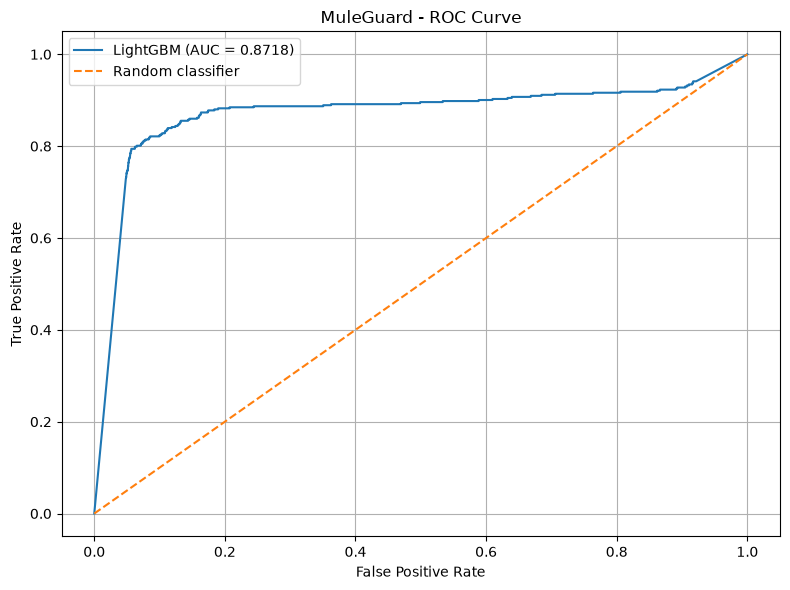

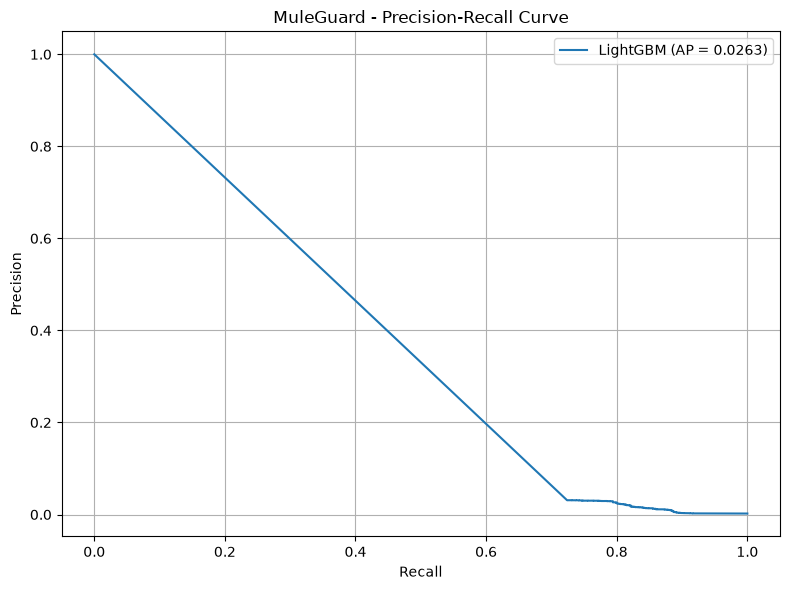


THRESHOLD ANALYSIS
 threshold  precision  recall     f1  specificity  false_positive_rate  false_negative_rate  TP     TN    FP  FN
    0.1000     0.0241  0.8009 0.0467       0.9310               0.0690               0.1991 354 193532 14351  88
    0.1500     0.0246  0.8009 0.0478       0.9326               0.0674               0.1991 354 193873 14010  88
    0.2000     0.0251  0.8009 0.0487       0.9338               0.0662               0.1991 354 194131 13752  88
    0.2500     0.0254  0.8009 0.0493       0.9347               0.0653               0.1991 354 194316 13567  88
    0.3000     0.0256  0.7986 0.0497       0.9354               0.0646               0.2014 353 194462 13421  89
    0.3500     0.0259  0.7986 0.0502       0.9362               0.0638               0.2014 353 194619 13264  89
    0.4000     0.0262  0.7986 0.0508       0.9369               0.0631               0.2014 353 194767 13116  89
    0.4500     0.0264  0.7986 0.0512       0.9375               0.0625      

In [164]:
# ============================================================
# MULEGUARD - COMPLETE LIGHTGBM MODEL EVALUATION REPORT
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)

# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

print("=" * 60)
print("MULEGUARD MODEL EVALUATION")
print("=" * 60)

required_variables = ["model", "X_test", "y_test"]

for variable in required_variables:
    if variable not in globals():
        raise NameError(
            f"'{variable}' is not defined. "
            f"Load/create it before running this evaluation."
        )

print("\nRequired variables: PASSED")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# ============================================================
# 2. BASIC DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

n_samples = len(X_test)
n_features = X_test.shape[1]

print("Test samples:", n_samples)
print("Features:", n_features)

# Convert labels to numpy
y_true = np.asarray(y_test).astype(int).ravel()

unique_classes, class_counts = np.unique(y_true, return_counts=True)

print("\nClass distribution:")

for cls, count in zip(unique_classes, class_counts):
    percentage = (count / len(y_true)) * 100
    print(f"Class {cls}: {count:,} " f"({percentage:.2f}%)")

if len(unique_classes) == 2:
    negative_count = np.sum(y_true == 0)
    positive_count = np.sum(y_true == 1)

    imbalance_ratio = negative_count / positive_count if positive_count > 0 else np.inf

    print("\nNegative samples:", negative_count)
    print("Positive samples:", positive_count)
    print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")


# ============================================================
# 3. GENERATE PREDICTIONS
# ============================================================

print("\n" + "=" * 60)
print("GENERATING PREDICTIONS")
print("=" * 60)

y_probability = model.predict(X_test)

# Make sure predictions are 1D
y_probability = np.asarray(y_probability).ravel()

# Default classification threshold
threshold = 0.50

y_pred = (y_probability >= threshold).astype(int)

print("Prediction shape:", y_probability.shape)
print("Threshold:", threshold)
print("Predictions generated: PASSED")


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

print("\n                 Predicted")
print("              Normal   Mule")
print(f"Actual Normal  {tn:7d} {fp:7d}")
print(f"Actual Mule    {fn:7d} {tp:7d}")

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


# ============================================================
# 5. CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, zero_division=0)

recall = recall_score(y_true, y_pred, zero_division=0)

f1 = f1_score(y_true, y_pred, zero_division=0)

balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

mcc = matthews_corrcoef(y_true, y_pred)

kappa = cohen_kappa_score(y_true, y_pred)

# Specificity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# False positive / negative rates
fpr_value = fp / (fp + tn) if (fp + tn) > 0 else 0

fnr_value = fn / (fn + tp) if (fn + tp) > 0 else 0

# AUC metrics
roc_auc = roc_auc_score(y_true, y_probability)

pr_auc = average_precision_score(y_true, y_probability)

# Probability metrics
logloss = log_loss(y_true, y_probability)

brier = brier_score_loss(y_true, y_probability)


# ============================================================
# 6. PRINT METRICS
# ============================================================

print("\n" + "=" * 60)
print("LIGHTGBM PERFORMANCE METRICS")
print("=" * 60)

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall / Sensitivity": recall,
    "F1 Score": f1,
    "Specificity": specificity,
    "Balanced Accuracy": balanced_accuracy,
    "ROC-AUC": roc_auc,
    "PR-AUC / Average Precision": pr_auc,
    "Matthews Correlation Coefficient": mcc,
    "Cohen's Kappa": kappa,
    "Log Loss": logloss,
    "Brier Score": brier,
    "False Positive Rate": fpr_value,
    "False Negative Rate": fnr_value,
}

for name, value in metrics.items():
    print(f"{name:<32}: {value:.6f}")


# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true, y_pred, target_names=["Normal", "Mule"], zero_division=0
    )
)


# ============================================================
# 8. ROC CURVE
# ============================================================

fpr_curve, tpr_curve, roc_thresholds = roc_curve(y_true, y_probability)

plt.figure(figsize=(8, 6))

plt.plot(fpr_curve, tpr_curve, label=f"LightGBM (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MuleGuard - ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


# ============================================================
# 9. PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_true, y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(recall_curve, precision_curve, label=f"LightGBM (AP = {pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("MuleGuard - Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


# ============================================================
# 10. THRESHOLD ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("THRESHOLD ANALYSIS")
print("=" * 60)

thresholds_to_test = np.arange(0.10, 1.00, 0.05)

threshold_results = []

for t in thresholds_to_test:

    predictions = (y_probability >= t).astype(int)

    cm_t = confusion_matrix(y_true, predictions, labels=[0, 1])

    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

    precision_t = precision_score(y_true, predictions, zero_division=0)

    recall_t = recall_score(y_true, predictions, zero_division=0)

    f1_t = f1_score(y_true, predictions, zero_division=0)

    specificity_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0

    threshold_results.append(
        {
            "threshold": round(t, 2),
            "precision": precision_t,
            "recall": recall_t,
            "f1": f1_t,
            "specificity": specificity_t,
            "false_positive_rate": 1 - specificity_t,
            "false_negative_rate": (1 - recall_t),
            "TP": tp_t,
            "TN": tn_t,
            "FP": fp_t,
            "FN": fn_t,
        }
    )

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# ============================================================
# 11. BEST THRESHOLD BY F1
# ============================================================

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]

print("\n" + "=" * 60)
print("BEST THRESHOLD")
print("=" * 60)

print(f"Best threshold: {best_row['threshold']:.2f}")

print(f"Precision:      {best_row['precision']:.4f}")

print(f"Recall:         {best_row['recall']:.4f}")

print(f"F1:             {best_row['f1']:.4f}")

print(f"Specificity:    {best_row['specificity']:.4f}")


# ============================================================
# 12. SAVE THRESHOLD REPORT
# ============================================================

os.makedirs("evaluation", exist_ok=True)

threshold_path = "evaluation/lightgbm_threshold_analysis.csv"

threshold_df.to_csv(threshold_path, index=False)

print("\nThreshold report saved:", threshold_path)


# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 60)
print("LIGHTGBM FEATURE IMPORTANCE")
print("=" * 60)

try:

    # Native LightGBM Booster
    feature_names = model.feature_name()

    gain_importance = model.feature_importance(importance_type="gain")

    split_importance = model.feature_importance(importance_type="split")

    feature_importance_df = pd.DataFrame(
        {"feature": feature_names, "gain": gain_importance, "split": split_importance}
    )

    feature_importance_df = feature_importance_df.sort_values(
        "gain", ascending=False
    ).reset_index(drop=True)

    print(feature_importance_df.to_string(index=False))

    feature_importance_df.to_csv(
        "evaluation/lightgbm_feature_importance.csv", index=False
    )

    print("\nFeature importance saved:" " evaluation/lightgbm_feature_importance.csv")

except Exception as e:

    print("\nNative LightGBM feature importance " "could not be generated.")

    print("Reason:", e)


# ============================================================
# 14. SHAP IMPORTANCE
# ============================================================

shap_importance_path = "evaluation/shap_feature_importance.csv"

if os.path.exists(shap_importance_path):

    print("\n" + "=" * 60)
    print("SHAP FEATURE IMPORTANCE")
    print("=" * 60)

    shap_df = pd.read_csv(shap_importance_path)

    print(shap_df.head(20).to_string(index=False))

else:

    print("\nSHAP feature importance CSV not found.")
    print("Your previously calculated SHAP values can " "be exported separately.")


# ============================================================
# 15. SAVE COMPLETE METRICS JSON
# ============================================================

report = {
    "model": "LightGBM",
    "test_samples": int(n_samples),
    "features": int(n_features),
    "threshold": float(threshold),
    "confusion_matrix": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
    "metrics": {key: float(value) for key, value in metrics.items()},
    "best_threshold": {
        "threshold": float(best_row["threshold"]),
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "f1": float(best_row["f1"]),
        "specificity": float(best_row["specificity"]),
    },
}

with open("evaluation/lightgbm_evaluation_report.json", "w") as f:

    json.dump(report, f, indent=4)


# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("MULEGUARD EVALUATION COMPLETE")
print("=" * 60)

print(f"Samples evaluated : {n_samples:,}")
print(f"Features           : {n_features}")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1                 : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"PR-AUC             : {pr_auc:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"MCC                : {mcc:.4f}")

print("\nFiles generated:")
print("evaluation/lightgbm_threshold_analysis.csv")
print("evaluation/lightgbm_evaluation_report.json")
print("evaluation/lightgbm_feature_importance.csv")

print("\nEvaluation completed successfully.")

In [169]:
# ============================================================
# MULEGUARD V1 — DETERMINE ORIGINAL CATEGORICAL ENCODING
# ============================================================

import joblib
import pandas as pd

model = joblib.load("models/lightgbm_model.pkl")

print("=" * 70)
print("V1 MODEL CATEGORICAL DIAGNOSTIC")
print("=" * 70)

print("\nModel pandas_categorical:")
print(model.booster_.pandas_categorical)

print("\nModel parameters:")
params = model.get_params()

for key in ["categorical_feature", "feature_name", "verbosity"]:
    print(f"{key}: {params.get(key)}")

print("\nBooster categorical feature:")
print(model.booster_.params.get("categorical_feature"))

print("\nModel feature names:")
print(model.feature_name_)

# ------------------------------------------------------------
# Check the actual dataframe BEFORE modifying anything
# ------------------------------------------------------------

categorical_cols = ["receiving_currency", "payment_currency", "payment_format"]

print("\n" + "=" * 70)
print("CURRENT DATAFRAME DTYPES")
print("=" * 70)

for col in categorical_cols:
    print(f"{col}: dtype={df[col].dtype}, " f"example={df[col].iloc[0]!r}")

# ------------------------------------------------------------
# Check unique values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ACTUAL VALUES IN DF")
print("=" * 70)

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(20))

V1 MODEL CATEGORICAL DIAGNOSTIC

Model pandas_categorical:
[]

Model parameters:
categorical_feature: None
feature_name: None
verbosity: -1

Booster categorical feature:
None

Model feature names:
['from_bank', 'to_bank', 'amount_received', 'receiving_currency', 'amount_paid', 'payment_currency', 'payment_format', 'hour', 'day_of_week', 'amount_diff', 'amount_ratio', 'currency_match', 'same_bank', 'sender_transaction_count', 'sender_total_amount', 'sender_avg_amount', 'sender_max_amount', 'sender_unique_receivers', 'sender_unique_banks', 'receiver_transaction_count', 'receiver_total_amount', 'receiver_avg_amount', 'receiver_max_amount', 'receiver_unique_senders', 'receiver_unique_banks', 'seconds_since_previous']

CURRENT DATAFRAME DTYPES
receiving_currency: dtype=object, example='US Dollar'
payment_currency: dtype=object, example='US Dollar'
payment_format: dtype=object, example='Cheque'

ACTUAL VALUES IN DF

receiving_currency
receiving_currency
US Dollar            1879341
Euro     

In [170]:
# ============================================================
# MULEGUARD V1 — INSPECT SAVED FEATURE CONFIG
# ============================================================

import joblib

CONFIG_PATH = "models/feature_config.pkl"

config = joblib.load(CONFIG_PATH)

print("=" * 70)
print("V1 FEATURE CONFIG")
print("=" * 70)

print("Type:", type(config))

if isinstance(config, dict):

    print("\nKeys:")
    for key in config.keys():
        print(" -", key)

    print("\nFull configuration:")
    for key, value in config.items():
        print(f"\n[{key}]")
        print(value)

else:
    print("\nConfiguration contents:")
    print(config)

V1 FEATURE CONFIG
Type: <class 'dict'>

Keys:
 - version
 - features
 - feature_count
 - categorical_features
 - target
 - best_threshold
 - best_f1
 - roc_auc
 - pr_auc

Full configuration:

[version]
temporal_v2

[features]
['from_bank', 'to_bank', 'amount_received', 'receiving_currency', 'amount_paid', 'payment_currency', 'payment_format', 'hour', 'day_of_week', 'amount_diff', 'amount_ratio', 'currency_match', 'same_bank', 'sender_transaction_count', 'sender_total_amount', 'sender_avg_amount', 'sender_max_amount', 'sender_unique_receivers', 'sender_unique_banks', 'receiver_transaction_count', 'receiver_total_amount', 'receiver_avg_amount', 'receiver_max_amount', 'receiver_unique_senders', 'receiver_unique_banks', 'seconds_since_previous']

[feature_count]
26

[categorical_features]
['receiving_currency', 'payment_currency', 'payment_format']

[target]
is_laundering

[best_threshold]
0.5

[best_f1]
0.023955380817408795

[roc_auc]
0.8038404701439581

[pr_auc]
0.009592827854903433


In [171]:
# ============================================================
# MULEGUARD V1 — INSPECT MODEL + AVAILABLE ENCODER FILES
# ============================================================

import joblib
import os

print("=" * 70)
print("MULEGUARD V1 PREPROCESSING CHECK")
print("=" * 70)

# ------------------------------------------------------------
# Check model files
# ------------------------------------------------------------

for path in [
    "models/lightgbm_model.pkl",
    "models/shap_explainer.pkl",
    "models/feature_config.pkl",
    "models/category_encoders.pkl",
]:

    print(f"\n{path}")

    if os.path.exists(path):

        print("  ✓ EXISTS")

        try:
            obj = joblib.load(path)

            print("  Type:", type(obj))

            if isinstance(obj, dict):
                print("  Keys:", list(obj.keys()))

        except Exception as e:
            print("  Could not inspect:", e)

    else:
        print("  ✗ NOT FOUND")


# ------------------------------------------------------------
# Inspect category_encoders.pkl if present
# ------------------------------------------------------------

encoder_path = "models/category_encoders.pkl"

if os.path.exists(encoder_path):

    print("\n" + "=" * 70)
    print("CATEGORY ENCODERS")
    print("=" * 70)

    encoders = joblib.load(encoder_path)

    print("Type:", type(encoders))

    if isinstance(encoders, dict):

        for name, encoder in encoders.items():

            print(f"\n{name}")
            print("Type:", type(encoder))

            if hasattr(encoder, "classes_"):
                print("Classes:")
                print(list(encoder.classes_))

            elif hasattr(encoder, "categories_"):
                print("Categories:")
                print(encoder.categories_)

            else:
                print("Object:", encoder)

MULEGUARD V1 PREPROCESSING CHECK

models/lightgbm_model.pkl
  ✓ EXISTS
  Type: <class 'lightgbm.sklearn.LGBMClassifier'>

models/shap_explainer.pkl
  ✓ EXISTS
  Type: <class 'shap.explainers._tree.TreeExplainer'>

models/feature_config.pkl
  ✓ EXISTS
  Type: <class 'dict'>
  Keys: ['version', 'features', 'feature_count', 'categorical_features', 'target', 'best_threshold', 'best_f1', 'roc_auc', 'pr_auc']

models/category_encoders.pkl
  ✓ EXISTS
  Type: <class 'dict'>
  Keys: ['receiving_currency', 'payment_currency', 'payment_format']

CATEGORY ENCODERS
Type: <class 'dict'>

receiving_currency
Type: <class 'dict'>
Object: {'Australian Dollar': 0, 'Bitcoin': 1, 'Brazil Real': 2, 'Canadian Dollar': 3, 'Euro': 4, 'Mexican Peso': 5, 'Ruble': 6, 'Rupee': 7, 'Saudi Riyal': 8, 'Shekel': 9, 'Swiss Franc': 10, 'UK Pound': 11, 'US Dollar': 12, 'Yen': 13, 'Yuan': 14}

payment_currency
Type: <class 'dict'>
Object: {'Australian Dollar': 0, 'Bitcoin': 1, 'Brazil Real': 2, 'Canadian Dollar': 3, 'Euro'

In [172]:
# ============================================================
# MULEGUARD V1 — FINAL DUMMY PREDICTION TEST
# Uses the EXACT saved V1 categorical encoders
# Does NOT modify any model files
# ============================================================

import joblib
import pandas as pd
import numpy as np

MODEL_PATH = "models/lightgbm_model.pkl"
ENCODER_PATH = "models/category_encoders.pkl"
CONFIG_PATH = "models/feature_config.pkl"

# ------------------------------------------------------------
# 1. Load V1 artifacts
# ------------------------------------------------------------

model = joblib.load(MODEL_PATH)
encoders = joblib.load(ENCODER_PATH)
config = joblib.load(CONFIG_PATH)

print("=" * 70)
print("MULEGUARD V1 — FINAL DUMMY TEST")
print("=" * 70)

print("✓ V1 model loaded")
print("✓ V1 categorical encoders loaded")

FEATURES = config["features"]

print("Features:", len(FEATURES))


# ------------------------------------------------------------
# 2. Select 3 real rows as dummy transactions
# ------------------------------------------------------------

# Uses your already-loaded df
dummy = df.sample(n=3, random_state=42).copy()

print("\nDummy rows selected:")
print(
    dummy[
        [
            "from_bank",
            "to_bank",
            "amount_received",
            "receiving_currency",
            "amount_paid",
            "payment_currency",
            "payment_format",
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 3. Apply EXACT V1 categorical mappings
# ------------------------------------------------------------

categorical_features = [
    "receiving_currency",
    "payment_currency",
    "payment_format",
]

for feature in categorical_features:

    mapping = encoders[feature]

    print(f"\nEncoding {feature}...")

    # Check for unknown values
    unknown = set(dummy[feature].dropna().unique()) - set(mapping.keys())

    if unknown:
        raise ValueError(f"Unknown values found in {feature}: {unknown}")

    dummy[feature] = dummy[feature].map(mapping)

    if dummy[feature].isna().any():
        raise ValueError(f"NaN produced while encoding {feature}")

print("\n✓ Exact V1 categorical encoding applied")


# ------------------------------------------------------------
# 4. Build model input
# ------------------------------------------------------------

X_dummy = dummy[FEATURES].copy()


# ------------------------------------------------------------
# 5. Force numeric dtypes
# ------------------------------------------------------------

for col in X_dummy.columns:
    X_dummy[col] = pd.to_numeric(X_dummy[col], errors="raise")

print("\nFinal dtypes:")
print(X_dummy.dtypes)


# ------------------------------------------------------------
# 6. Verify feature order
# ------------------------------------------------------------

model_features = list(model.feature_name_)

if model_features != FEATURES:

    print("\nWARNING: Feature order mismatch")

    print("Model:")
    print(model_features)

    print("\nConfig:")
    print(FEATURES)

    raise ValueError("Model feature order does not match feature_config.pkl")

print("\n✓ Feature order matches V1 model")
print("✓ Feature count:", X_dummy.shape[1])


# ------------------------------------------------------------
# 7. Generate predictions
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERATING V1 PREDICTIONS")
print("=" * 70)

probabilities = model.predict_proba(X_dummy)[:, 1]


# ------------------------------------------------------------
# 8. Threshold
# ------------------------------------------------------------

threshold = config["best_threshold"]

predictions = (probabilities >= threshold).astype(int)


# ------------------------------------------------------------
# 9. Risk score
# ------------------------------------------------------------

risk_scores = probabilities * 100

risk_labels = np.where(predictions == 1, "MULE / SUSPICIOUS", "NORMAL")


# ------------------------------------------------------------
# 10. Results
# ------------------------------------------------------------

results = dummy[
    [
        "from_bank",
        "to_bank",
        "amount_received",
        "receiving_currency",
        "amount_paid",
        "payment_currency",
        "payment_format",
    ]
].copy()

results["risk_probability"] = probabilities
results["risk_score"] = risk_scores
results["threshold"] = threshold
results["prediction"] = risk_labels


print("\n" + "=" * 70)
print("MULEGUARD V1 DUMMY TEST RESULTS")
print("=" * 70)

print(
    results.to_string(
        index=False,
        formatters={
            "risk_probability": "{:.6f}".format,
            "risk_score": "{:.2f}".format,
            "threshold": "{:.2f}".format,
        },
    )
)


# ------------------------------------------------------------
# 11. Basic validation
# ------------------------------------------------------------

assert len(probabilities) == 3
assert np.all(probabilities >= 0)
assert np.all(probabilities <= 1)
assert X_dummy.shape[1] == 26

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print("✓ Model prediction executed successfully")
print("✓ 3 transactions tested")
print("✓ 26 features supplied")
print("✓ Exact V1 categorical mappings used")
print("✓ Probabilities are valid [0, 1]")
print(f"✓ V1 threshold: {threshold}")

print("\n" + "=" * 70)
print("V1 DUMMY TEST COMPLETE")
print("=" * 70)

MULEGUARD V1 — FINAL DUMMY TEST
✓ V1 model loaded
✓ V1 categorical encoders loaded
Features: 26

Dummy rows selected:
 from_bank  to_bank  amount_received receiving_currency  amount_paid payment_currency payment_format
       410       23      7647.080078               Euro  7647.080078             Euro         Cheque
        19    24779        11.140000    Canadian Dollar    11.140000  Canadian Dollar         Cheque
        20       20      3604.800049               Euro  3604.800049             Euro         Cheque

Encoding receiving_currency...

Encoding payment_currency...

Encoding payment_format...

✓ Exact V1 categorical encoding applied

Final dtypes:
from_bank                       int32
to_bank                         int32
amount_received               float32
receiving_currency              int64
amount_paid                   float32
payment_currency                int64
payment_format                  int64
hour                             int8
day_of_week                 

In [178]:
# ================================================================
# MULEGUARD V1 — 3 REAL MULE + 3 NORMAL
# PREDICTION + SHAP EXPLANATION
#
# IMPORTANT:
# Uses LightGBM Booster directly for SHAP.
# Does NOT use saved TreeExplainer.shap_values()
# This avoids the categorical metadata mismatch.
# ================================================================

import os
import joblib
import numpy as np
import pandas as pd

print("=" * 75)
print("MULEGUARD V1 — REAL TRANSACTION + SHAP TEST")
print("=" * 75)


# ================================================================
# 1. LOAD V1 ARTIFACTS
# ================================================================

MODEL_PATH = "models/lightgbm_model.pkl"
CONFIG_PATH = "models/feature_config.pkl"
ENCODER_PATH = "models/category_encoders.pkl"

model = joblib.load(MODEL_PATH)
feature_config = joblib.load(CONFIG_PATH)
encoders = joblib.load(ENCODER_PATH)

FEATURES = feature_config["features"]
CAT_COLS = feature_config["categorical_features"]
THRESHOLD = feature_config.get("best_threshold", 0.5)

print("✓ V1 model loaded")
print("✓ Feature config loaded")
print("✓ Category encoders loaded")

print("\nFeatures:", len(FEATURES))
print("Categorical:", CAT_COLS)
print("Threshold:", THRESHOLD)


# ================================================================
# 2. VERIFY DATAFRAME
# ================================================================

if "df" not in globals():
    raise RuntimeError(
        "DataFrame 'df' is not loaded. Load your transaction dataframe first."
    )

required_cols = FEATURES + ["is_laundering"]

missing = [col for col in required_cols if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("✓ Required dataframe columns available")


# ================================================================
# 3. SELECT 3 REAL MULE + 3 REAL NORMAL
# ================================================================

mules = df[df["is_laundering"] == 1]

normals = df[df["is_laundering"] == 0]

if len(mules) < 3:
    raise ValueError("Dataset contains fewer than 3 mule transactions.")

if len(normals) < 3:
    raise ValueError("Dataset contains fewer than 3 normal transactions.")

mule_sample = mules.sample(n=3, random_state=42)

normal_sample = normals.sample(n=3, random_state=42)

test_df = pd.concat([mule_sample, normal_sample], axis=0).copy()

test_df = test_df.reset_index(drop=False)

print("\n" + "=" * 75)
print("SELECTED REAL TRANSACTIONS")
print("=" * 75)

display_cols = [
    "sender_account",
    "receiver_account",
    "amount_received",
    "amount_paid",
    "payment_format",
    "is_laundering",
]

print(test_df[display_cols].to_string(index=False))


# ================================================================
# 4. CREATE MODEL INPUT
# ================================================================

X_test = test_df[FEATURES].copy()


# ================================================================
# 5. APPLY EXACT V1 CATEGORY ENCODERS
# ================================================================

print("\n" + "=" * 75)
print("APPLYING EXACT V1 CATEGORY ENCODING")
print("=" * 75)

for col in CAT_COLS:

    if col not in encoders:
        raise ValueError(f"Encoder missing for {col}")

    mapping = encoders[col]

    print(f"{col}: {len(mapping)} categories")

    # Check unseen categories
    unique_values = set(X_test[col].dropna().unique())

    unseen = unique_values - set(mapping.keys())

    if unseen:
        raise ValueError(f"Unseen values in {col}: {unseen}")

    X_test[col] = X_test[col].map(mapping)

    if X_test[col].isna().any():
        raise ValueError(f"NaN produced while encoding {col}")

    X_test[col] = X_test[col].astype(np.int64)


# ================================================================
# 6. NUMERIC CLEANING
# ================================================================

for col in FEATURES:

    if col in CAT_COLS:
        continue

    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

if X_test.isna().any().any():

    bad = X_test.columns[X_test.isna().any()].tolist()

    raise ValueError(f"NaN values found in: {bad}")


# ================================================================
# 7. EXACT FEATURE ORDER
# ================================================================

X_test = X_test[FEATURES].copy()

print("\n✓ Feature order verified")
print("✓ Feature count:", X_test.shape[1])

if list(X_test.columns) != list(FEATURES):
    raise ValueError("Feature order does not match V1 model.")

print("✓ Feature order matches V1")


# ================================================================
# 8. V1 PREDICTION
# ================================================================

print("\n" + "=" * 75)
print("GENERATING V1 PREDICTIONS")
print("=" * 75)

probabilities = model.predict_proba(X_test)[:, 1]

predictions = (probabilities >= THRESHOLD).astype(int)

print("✓ Predictions generated")


# ================================================================
# 9. SHAP USING LIGHTGBM BOOSTER DIRECTLY
# ================================================================

print("\n" + "=" * 75)
print("GENERATING SHAP VALUES")
print("=" * 75)

# ------------------------------------------------
# IMPORTANT
#
# Do NOT use:
#
# explainer.shap_values(X_test)
#
# because the saved TreeExplainer contains
# incompatible categorical metadata.
#
# Instead, use LightGBM's native pred_contrib.
# ------------------------------------------------

booster = model.booster_

print("Booster type:", type(booster))

shap_raw = booster.predict(X_test, pred_contrib=True)

shap_raw = np.asarray(shap_raw)

print("Raw SHAP shape:", shap_raw.shape)


# ------------------------------------------------
# LightGBM pred_contrib returns:
#
# [feature1, feature2, ..., feature26, bias]
#
# Therefore remove final bias column.
# ------------------------------------------------

if shap_raw.shape[1] != len(FEATURES) + 1:

    raise ValueError(
        f"Unexpected SHAP shape: {shap_raw.shape}. "
        f"Expected (*, {len(FEATURES) + 1})."
    )

shap_matrix = shap_raw[:, :-1]

base_values = shap_raw[:, -1]

print("✓ SHAP matrix created")
print("SHAP matrix shape:", shap_matrix.shape)
print("✓ Bias/base values extracted")


# ================================================================
# 10. RESULTS
# ================================================================

results = test_df[
    [
        "sender_account",
        "receiver_account",
        "amount_received",
        "amount_paid",
        "payment_format",
        "is_laundering",
    ]
].copy()

results["risk_probability"] = probabilities

results["risk_score"] = probabilities * 100

results["prediction"] = np.where(predictions == 1, "MULE / SUSPICIOUS", "NORMAL")

results["actual"] = np.where(results["is_laundering"] == 1, "MULE", "NORMAL")

print("\n" + "=" * 75)
print("MULEGUARD V1 PREDICTIONS")
print("=" * 75)

print(
    results[
        [
            "sender_account",
            "receiver_account",
            "amount_received",
            "payment_format",
            "actual",
            "risk_probability",
            "risk_score",
            "prediction",
        ]
    ].to_string(index=False)
)


# ================================================================
# 11. TOP SHAP FEATURES FOR EACH TRANSACTION
# ================================================================

print("\n" + "=" * 75)
print("TOP SHAP EXPLANATIONS")
print("=" * 75)

all_shap_rows = []

for i in range(len(X_test)):

    actual = int(test_df.iloc[i]["is_laundering"])

    probability = probabilities[i]

    print("\n" + "-" * 75)

    print(f"TRANSACTION {i + 1}")

    print(f"Actual      : " f"{'MULE' if actual == 1 else 'NORMAL'}")

    print(
        f"Prediction  : " f"{'MULE / SUSPICIOUS' if predictions[i] == 1 else 'NORMAL'}"
    )

    print(f"Probability : {probability:.6f}")

    print(f"Risk Score  : {probability * 100:.2f}/100")

    # Top 10 absolute SHAP contributors
    top_indices = np.argsort(np.abs(shap_matrix[i]))[::-1][:10]

    print("\nTop contributing features:")

    for rank, idx in enumerate(top_indices, start=1):

        feature = FEATURES[idx]

        value = X_test.iloc[i, idx]

        shap_value = shap_matrix[i, idx]

        direction = "INCREASES RISK" if shap_value > 0 else "DECREASES RISK"

        print(
            f"{rank:2}. "
            f"{feature:<30} "
            f"value={value:<12} "
            f"SHAP={shap_value: .6f} "
            f"{direction}"
        )

        all_shap_rows.append(
            {
                "transaction": i + 1,
                "actual": ("MULE" if actual == 1 else "NORMAL"),
                "prediction": ("MULE" if predictions[i] == 1 else "NORMAL"),
                "risk_probability": probability,
                "feature": feature,
                "feature_value": value,
                "shap_value": shap_value,
                "direction": direction,
            }
        )


# ================================================================
# 12. SHAP SUMMARY DATAFRAME
# ================================================================

shap_summary = pd.DataFrame(all_shap_rows)

print("\n" + "=" * 75)
print("SHAP SUMMARY")
print("=" * 75)

display(shap_summary)


# ================================================================
# 13. SAVE EXPLANATIONS
# ================================================================

os.makedirs("evaluation", exist_ok=True)

output_path = "evaluation/" "v1_real_transaction_shap.csv"

shap_summary.to_csv(output_path, index=False)

print("\n✓ SHAP explanations saved:")
print(output_path)


# ================================================================
# 14. FINAL VALIDATION
# ================================================================

print("\n" + "=" * 75)
print("VALIDATION")
print("=" * 75)

print("✓ 3 real mule transactions")
print("✓ 3 real normal transactions")
print("✓ Exact V1 category encoders")
print("✓ 26 V1 features")
print("✓ V1 prediction successful")
print("✓ Native LightGBM SHAP successful")
print("✓ Top SHAP contributors generated")
print("✓ No matplotlib required")
print("✓ Results saved to CSV")

print("\n" + "=" * 75)
print("MULEGUARD V1 REAL SHAP TEST COMPLETE")
print("=" * 75)

MULEGUARD V1 — REAL TRANSACTION + SHAP TEST
✓ V1 model loaded
✓ Feature config loaded
✓ Category encoders loaded

Features: 26
Categorical: ['receiving_currency', 'payment_currency', 'payment_format']
Threshold: 0.5
✓ Required dataframe columns available

SELECTED REAL TRANSACTIONS
sender_account receiver_account  amount_received  amount_paid payment_format  is_laundering
     80E5157A0        808CB27A0      9321.389648  9321.389648            ACH              1
     80A98C410        8079DDC30     15914.759766 15914.759766            ACH              1
     80B0C3F40        811D80C30     23526.060547 23526.060547            ACH              1
     8010CF900        8016DF1E0       721.260010   721.260010         Cheque              0
     8127403D0        8007ED470         2.780000     2.780000    Credit Card              0
     80BD350D0        80BD3EB70      2077.709961  2077.709961    Credit Card              0

APPLYING EXACT V1 CATEGORY ENCODING
receiving_currency: 15 categories
pa

,transaction,actual,prediction,risk_probability,feature,feature_value,shap_value,direction
0,1,MULE,NORMAL,3.824477e-22,payment_format,0.000000e+00,4772.251156,INCREASES RISK
1,1,MULE,NORMAL,3.824477e-22,seconds_since_previous,0.000000e+00,2554.743566,INCREASES RISK
2,1,MULE,NORMAL,3.824477e-22,sender_unique_receivers,3.000000e+00,-2037.845417,DECREASES RISK
3,1,MULE,NORMAL,3.824477e-22,sender_max_amount,1.236644e+05,1924.234971,INCREASES RISK
4,1,MULE,NORMAL,3.824477e-22,sender_unique_banks,3.000000e+00,1435.373822,INCREASES RISK
5,1,MULE,NORMAL,3.824477e-22,sender_transaction_count,6.000000e+00,-1307.421054,DECREASES RISK
6,1,MULE,NORMAL,3.824477e-22,amount_paid,9.321390e+03,-763.855298,DECREASES RISK
7,1,MULE,NORMAL,3.824477e-22,amount_received,9.321390e+03,-522.262635,DECREASES RISK
8,1,MULE,NORMAL,3.824477e-22,sender_total_amount,1.738709e+05,-492.295080,DECREASES RISK
9,1,MULE,NORMAL,3.824477e-22,from_bank,1.170000e+02,264.999827,INCREASES RISK



✓ SHAP explanations saved:
evaluation/v1_real_transaction_shap.csv

VALIDATION
✓ 3 real mule transactions
✓ 3 real normal transactions
✓ Exact V1 category encoders
✓ 26 V1 features
✓ V1 prediction successful
✓ Native LightGBM SHAP successful
✓ Top SHAP contributors generated
✓ No matplotlib required
✓ Results saved to CSV

MULEGUARD V1 REAL SHAP TEST COMPLETE


In [182]:
# =====================================================================
# MULEGUARD — ALL 3 MODELS ROBUST EVALUATION
# Handles:
#   1. sklearn LGBMClassifier
#   2. native LightGBM Booster
#   3. Isolation Forest / saved anomaly scores
# =====================================================================

import os
import glob
import pickle
import joblib
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score,
)

warnings.filterwarnings("ignore")

print("=" * 75)
print("MULEGUARD — ALL 3 MODEL EVALUATION")
print("=" * 75)

# =====================================================================
# 1. FIND PROJECT
# =====================================================================

PROJECT_DIR = r"C:\Users\Raghav\OneDrive\Desktop\Projects\MuleGuard"
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
EVAL_DIR = os.path.join(PROJECT_DIR, "evaluation")

os.makedirs(EVAL_DIR, exist_ok=True)

print("\nProject:")
print(PROJECT_DIR)

print("\nModels:")
print(MODELS_DIR)

# =====================================================================
# 2. VERIFY DATAFRAME
# =====================================================================

if "df" not in globals():
    raise RuntimeError(
        "DataFrame 'df' is not available. " "Load the MuleGuard dataframe first."
    )

print("\nDataset:")
print("Shape:", df.shape)

TARGET = "is_laundering"

if TARGET not in df.columns:
    raise KeyError(f"'{TARGET}' not found in dataframe.")

# =====================================================================
# 3. LOAD FEATURE CONFIG
# =====================================================================

config_path = os.path.join(MODELS_DIR, "feature_config.pkl")

if os.path.exists(config_path):

    try:
        with open(config_path, "rb") as f:
            feature_config = pickle.load(f)

    except Exception:
        feature_config = joblib.load(config_path)

    FEATURES = feature_config["features"]

    CATEGORICAL_FEATURES = feature_config.get("categorical_features", [])

    THRESHOLD = feature_config.get("best_threshold", 0.5)

else:

    FEATURES = [
        "from_bank",
        "to_bank",
        "amount_received",
        "receiving_currency",
        "amount_paid",
        "payment_currency",
        "payment_format",
        "hour",
        "day_of_week",
        "amount_diff",
        "amount_ratio",
        "currency_match",
        "same_bank",
        "sender_transaction_count",
        "sender_total_amount",
        "sender_avg_amount",
        "sender_max_amount",
        "sender_unique_receivers",
        "sender_unique_banks",
        "receiver_transaction_count",
        "receiver_total_amount",
        "receiver_avg_amount",
        "receiver_max_amount",
        "receiver_unique_senders",
        "receiver_unique_banks",
        "seconds_since_previous",
    ]

    CATEGORICAL_FEATURES = [
        "receiving_currency",
        "payment_currency",
        "payment_format",
    ]

    THRESHOLD = 0.5

print("\n✓ Feature configuration loaded")
print("Feature count:", len(FEATURES))
print("Threshold:", THRESHOLD)

# =====================================================================
# 4. LOAD CATEGORY ENCODERS
# =====================================================================

encoder_path = os.path.join(MODELS_DIR, "category_encoders.pkl")

if os.path.exists(encoder_path):

    try:
        with open(encoder_path, "rb") as f:
            encoders = pickle.load(f)

    except Exception:
        encoders = joblib.load(encoder_path)

    print("\n✓ Category encoders loaded")

else:
    encoders = {}
    print("\n⚠ No category encoders found")

# =====================================================================
# 5. BUILD EVALUATION DATA
# =====================================================================

missing = [c for c in FEATURES if c not in df.columns]

if missing:
    raise KeyError("Missing features:\n" + "\n".join(missing))

# Reset EVERYTHING before boolean filtering.
# This prevents the previous IndexingError.

X_eval = df[FEATURES].copy().reset_index(drop=True)

y_eval = pd.to_numeric(df[TARGET], errors="coerce").reset_index(drop=True)

valid_mask = y_eval.notna().to_numpy()

X_eval = X_eval.iloc[valid_mask].reset_index(drop=True)

y_eval = y_eval.iloc[valid_mask].astype(int).reset_index(drop=True)

print("\nEvaluation data:")
print("Samples:", len(X_eval))
print("Features:", X_eval.shape[1])
print("Positive:", int(y_eval.sum()))
print("Negative:", int((y_eval == 0).sum()))

# =====================================================================
# 6. APPLY EXACT V1 ENCODING
# =====================================================================


def encode_features(X):

    X = X.copy()

    for col in CATEGORICAL_FEATURES:

        if col not in X.columns:
            continue

        if col in encoders:

            mapping = encoders[col]

            X[col] = X[col].map(mapping).fillna(-1).astype(np.int64)

        else:

            # Fallback only if encoder is unavailable.
            X[col] = pd.factorize(X[col], sort=True)[0].astype(np.int64)

    # Any remaining object/category columns
    # must be converted to numeric.

    for col in X.columns:

        if X[col].dtype == "object" or str(X[col].dtype) == "category":

            X[col] = pd.factorize(X[col], sort=True)[0].astype(np.int64)

    return X[FEATURES]


X_encoded = encode_features(X_eval)

print("\n✓ Features encoded")
print("Shape:", X_encoded.shape)

bad_cols = [
    c
    for c in X_encoded.columns
    if not (
        pd.api.types.is_numeric_dtype(X_encoded[c])
        or pd.api.types.is_bool_dtype(X_encoded[c])
    )
]

if bad_cols:
    raise TypeError("Non-numeric columns remain:\n" + str(bad_cols))

print("✓ All features numeric")

# =====================================================================
# 7. MODEL LOADER
# =====================================================================


def load_model(path):

    # First try joblib because some sklearn/lightgbm
    # files are saved with joblib.

    try:
        return joblib.load(path)
    except Exception:
        pass

    # Then try pickle.

    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception:
        pass

    # Native LightGBM fallback.

    if path.lower().endswith(".pkl"):

        try:
            import lightgbm as lgb

            return lgb.Booster(model_file=path)

        except Exception:
            pass

    raise RuntimeError(f"Could not load model:\n{path}")


# =====================================================================
# 8. PREDICTION HANDLER
# =====================================================================


def get_probabilities(model, X):

    # ---------------------------------------------------------------
    # sklearn LGBMClassifier
    # ---------------------------------------------------------------

    if hasattr(model, "predict_proba"):

        print("Prediction method: predict_proba")

        return np.asarray(model.predict_proba(X)[:, 1], dtype=float)

    # ---------------------------------------------------------------
    # Native LightGBM Booster
    # ---------------------------------------------------------------

    if hasattr(model, "predict"):

        print("Prediction method: native predict")

        scores = model.predict(X)

        scores = np.asarray(scores, dtype=float)

        # LightGBM binary Booster normally outputs
        # probabilities when objective=binary.

        return scores

    # ---------------------------------------------------------------
    # ndarray
    # ---------------------------------------------------------------

    if isinstance(model, np.ndarray):

        print("Prediction method: saved ndarray")

        scores = np.asarray(model, dtype=float)

        # If it contains one score per transaction,
        # use it directly.
        if len(scores) == len(X):
            return scores

        raise ValueError("Saved ndarray does not have " "one score per evaluation row.")

    raise TypeError("Unsupported model type: " + str(type(model)))


# =====================================================================
# 9. DISCOVER MODELS
# =====================================================================

MODEL_FILES = [
    "lightgbm_model.pkl",
    "muleguard_lightgbm.pkl",
    "muleguard_isolation_forest.pkl",
]

print("\n" + "=" * 75)
print("MODEL FILES")
print("=" * 75)

for name in MODEL_FILES:

    path = os.path.join(MODELS_DIR, name)

    print(f"{name}:", "✓ EXISTS" if os.path.exists(path) else "✗ MISSING")

# =====================================================================
# 10. EVALUATION
# =====================================================================

results = []
confusion_rows = []

for model_name in MODEL_FILES:

    path = os.path.join(MODELS_DIR, model_name)

    print("\n" + "=" * 75)
    print("EVALUATING:", model_name)
    print("=" * 75)

    if not os.path.exists(path):

        print("⚠ File not found")
        continue

    try:

        # -----------------------------------------------------------
        # LOAD
        # -----------------------------------------------------------

        model = load_model(path)

        print("✓ Loaded")
        print("Object type:", type(model))

        # -----------------------------------------------------------
        # IMPORTANT:
        # Your previous isolation forest file was an ndarray.
        # If it contains precomputed scores, those scores are NOT
        # necessarily aligned to the current dataframe after any
        # sorting/filtering.
        #
        # We therefore verify its length.
        # -----------------------------------------------------------

        probabilities = get_probabilities(model, X_encoded)

        probabilities = np.asarray(probabilities, dtype=float).reshape(-1)

        if len(probabilities) != len(y_eval):

            raise ValueError(
                f"Prediction length mismatch: "
                f"{len(probabilities)} predictions "
                f"for {len(y_eval)} rows."
            )

        # -----------------------------------------------------------
        # CLEAN SCORES
        # -----------------------------------------------------------

        probabilities = np.nan_to_num(probabilities, nan=0.0, posinf=1.0, neginf=0.0)

        # Native LightGBM should already be 0..1.
        # If scores aren't probabilities, normalize them.
        #
        # Isolation Forest decision scores commonly have the
        # opposite direction: lower = more anomalous.
        # Handle that separately below.

        is_isolation = "isolation" in model_name.lower()

        if is_isolation:

            raw_scores = probabilities.copy()

            # Isolation Forest anomaly convention:
            # lower decision_function = more anomalous.
            #
            # Convert to a ranking-compatible risk score.
            risk_scores = -raw_scores

            # Min-max normalize.
            mn = np.min(risk_scores)
            mx = np.max(risk_scores)

            if mx > mn:

                probabilities = (risk_scores - mn) / (mx - mn)

            else:

                probabilities = np.zeros(len(risk_scores))

            # For anomaly scores, 0.5 is used only as
            # a reporting threshold.
            threshold = 0.5

        else:

            # Keep LightGBM probabilities as-is.
            probabilities = np.clip(probabilities, 0.0, 1.0)

            threshold = THRESHOLD

        predictions = (probabilities >= threshold).astype(int)

        # -----------------------------------------------------------
        # CONFUSION MATRIX
        # -----------------------------------------------------------

        tn, fp, fn, tp = confusion_matrix(y_eval, predictions, labels=[0, 1]).ravel()

        # -----------------------------------------------------------
        # METRICS
        # -----------------------------------------------------------

        accuracy = accuracy_score(y_eval, predictions)

        precision = precision_score(y_eval, predictions, zero_division=0)

        recall = recall_score(y_eval, predictions, zero_division=0)

        f1 = f1_score(y_eval, predictions, zero_division=0)

        specificity = tn / (tn + fp) if tn + fp > 0 else 0

        balanced_accuracy = balanced_accuracy_score(y_eval, predictions)

        roc_auc = roc_auc_score(y_eval, probabilities)

        pr_auc = average_precision_score(y_eval, probabilities)

        mcc = matthews_corrcoef(y_eval, predictions)

        # -----------------------------------------------------------
        # STORE
        # -----------------------------------------------------------

        results.append(
            {
                "model": model_name,
                "model_type": type(model).__name__,
                "samples": len(y_eval),
                "features": len(FEATURES),
                "threshold": threshold,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "specificity": specificity,
                "balanced_accuracy": balanced_accuracy,
                "roc_auc": roc_auc,
                "pr_auc": pr_auc,
                "mcc": mcc,
                "TN": tn,
                "FP": fp,
                "FN": fn,
                "TP": tp,
            }
        )

        confusion_rows.append(
            {
                "model": model_name,
                "TN": tn,
                "FP": fp,
                "FN": fn,
                "TP": tp,
            }
        )

        # -----------------------------------------------------------
        # PRINT
        # -----------------------------------------------------------

        print("\n✓ PREDICTION SUCCESSFUL")

        print("\nMetrics")
        print("-" * 50)

        print(f"Accuracy          : {accuracy:.6f}")

        print(f"Precision         : {precision:.6f}")

        print(f"Recall            : {recall:.6f}")

        print(f"F1                : {f1:.6f}")

        print(f"Specificity       : {specificity:.6f}")

        print(f"Balanced Accuracy : {balanced_accuracy:.6f}")

        print(f"ROC-AUC           : {roc_auc:.6f}")

        print(f"PR-AUC            : {pr_auc:.6f}")

        print(f"MCC               : {mcc:.6f}")

        print("\nConfusion Matrix")
        print("-" * 50)

        print(f"TN: {tn:,}")

        print(f"FP: {fp:,}")

        print(f"FN: {fn:,}")

        print(f"TP: {tp:,}")

    except Exception as e:

        print("\n✗ EVALUATION FAILED")
        print(type(e).__name__, ":", str(e))

# =====================================================================
# 11. FINAL COMPARISON
# =====================================================================

print("\n")
print("=" * 75)
print("MULEGUARD — FINAL MODEL COMPARISON")
print("=" * 75)

if not results:

    print("\n⚠ No model produced valid predictions.")

else:

    results_df = pd.DataFrame(results)

    cols = [
        "model",
        "model_type",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "specificity",
        "balanced_accuracy",
        "roc_auc",
        "pr_auc",
        "mcc",
    ]

    print(results_df[cols].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

    # ---------------------------------------------------------------
    # SAVE
    # ---------------------------------------------------------------

    comparison_path = os.path.join(EVAL_DIR, "all_three_models_metrics.csv")

    confusion_path = os.path.join(EVAL_DIR, "all_three_models_confusion_matrix.csv")

    results_df.to_csv(comparison_path, index=False)

    pd.DataFrame(confusion_rows).to_csv(confusion_path, index=False)

    print("\n✓ Metrics saved:")
    print(comparison_path)

    print("\n✓ Confusion matrices saved:")
    print(confusion_path)

print("\n" + "=" * 75)
print("EVALUATION COMPLETE")
print("=" * 75)

MULEGUARD — ALL 3 MODEL EVALUATION

Project:
C:\Users\Raghav\OneDrive\Desktop\Projects\MuleGuard

Models:
C:\Users\Raghav\OneDrive\Desktop\Projects\MuleGuard\models

Dataset:
Shape: (5078345, 30)

✓ Feature configuration loaded
Feature count: 26
Threshold: 0.5

✓ Category encoders loaded

Evaluation data:
Samples: 5078345
Features: 26
Positive: 5177
Negative: 5073168

✓ Features encoded
Shape: (5078345, 26)
✓ All features numeric

MODEL FILES
lightgbm_model.pkl: ✓ EXISTS
muleguard_lightgbm.pkl: ✓ EXISTS
muleguard_isolation_forest.pkl: ✓ EXISTS

EVALUATING: lightgbm_model.pkl
✓ Loaded
Object type: <class 'lightgbm.sklearn.LGBMClassifier'>
Prediction method: predict_proba

✓ PREDICTION SUCCESSFUL

Metrics
--------------------------------------------------
Accuracy          : 0.886084
Precision         : 0.006128
Recall            : 0.687077
F1                : 0.012148
Specificity       : 0.886287
Balanced Accuracy : 0.786682
ROC-AUC           : 0.808434
PR-AUC            : 0.004844
MCC 